# ESc1: combined features, lagged model selection and holdout predictions

The joint model uses **[X, dszl(X, 10)]**: all 100 raw predictors, including cashflow/volume, followed by their 100 same-clock-time standardized counterparts. No raw feature is replaced by its transformed version.

Regularization is **selected anew for each forecast fold using the preceding completed test fold**, with two calendar years of training and two calendar years of frozen predictions. The first test fold is initial tuning only; its apparent winning performance is not reported as selected OOS performance. The chosen candidate is evaluated only in the following fold. Candidate selection minimizes raw-target mean squared error, not the capped-backtest Sharpe. Exact ties choose the larger penalty by grid order. One terminal validation row is embargoed for target maturity.

The first 80% of labeled elapsed time remains the research sample. The remaining labeled interval is kept out of the research charts, but **is used as the final pre-holdout validation fold** to choose the holdout regularization parameter. The final fit then uses the immediately preceding two years of labels and freezes coefficients throughout the true two-year price/label blackout. Earlier project versions inspected broader samples; the research reservation is not retrospectively pristine. Blackout labels are never used for fitting or selection.

Transformation experiments retain all research observations and all column pairs. Red TODOs remain explicit methodological limitations. The only prediction output is **`forecasts/predictions.parquet`**, containing timestamped raw `ret_5m` forecasts for the true holdout. Selection tables, validation diagnostics and parameters remain inside this notebook, not in sidecar files.


In [1]:
from pathlib import Path
import json, os, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
from scipy.cluster.hierarchy import dendrogram

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'takehome').exists())
sys.path.insert(0, str(ROOT / 'src'))
from takehome.data import column_coverage, training_data
from takehome.plots import heatmap
from takehome.eda import (
    acf_matrix, autocorrelation_table, bell_shape_table, correlation_clustering,
    correlation_to_column, infer_feature_cols, monthly_shift_scores, redundant_pairs,
)

DATA_PATH = Path(os.environ.get('DATA_PATH', ROOT / 'ESc1_signal_components_5min (6).parquet'))
SCATTER_N_FEATURES = 9  # Limit displayed columns, never observations.
ACF_LAG, SEASONAL_NLAGS = 15, 288
from takehome.features import ts_std, ewm_observed

get_ipython().run_line_magic('matplotlib', 'inline')
from IPython.display import display, Markdown
from takehome.data import read_parquet_window
from takehome.features import raw_dszl_design
from takehome.normalization import signal_weights

# Grids, transform and loss are declared before scoring; alpha is selected per fold.
HL, META_HL, DSZL_HL, WINDOW_YEARS, BATCH_SIZE = 6048, 252*288, 10, 2, 8
SIGNAL_RULE = dict(method='std', floor_fraction=.25, cap=3., lag=1)
RIDGE_CONFIG = dict(decay=2**(-1/HL), fit_intercept=True)
RIDGE_ALPHAS = np.logspace(2, -6, 9)  # Descending: exact ties prefer stronger regularization.
LASSO_ALPHAS = np.array([3e-4, 1e-4, 3e-5, 1e-5, 3e-6, 1e-6])
SELECTION_EMBARGO = 1


## Shared EWM and exposure convention

EWM scales treat **zeros and nonfinite observations as missing**, use `ignore_na=True`, and require the stated number of observations. Exactly zero standard deviations remain undefined. `dszl(10)` uses this convention independently within each local clock-time group, including the currently observed feature; it does not use a return or future feature.

All main backtest plots now use the **same signal-only rule** carried over from the normalization comparison:

$$w_t=\operatorname{clip}\left(\frac{s_t}{\max(\widehat\sigma_{s,t-1},0.25\,\sigma_0)},-3,3\right),\qquad p_t=w_tR_t.$$

Here $\sigma_0$ is the **first valid lagged** signal scale and is then frozen. No full-period scale is fitted. The half-life/minimum observations are 6,048; missing signals remain missing and a current zero signal gives zero exposure after warm-up. The cap is an explicit exposure budget, not P&L clipping or a claim of constant asset risk. Thus $|p_t|\le3|R_t|$ on observed bars, but a genuine large return can still produce a large contribution. Daily all-missing sums retain the existing zero convention.

The old normalization notebook's **Original shape** control was $\sigma_0s_t/\sigma_{s,t}^2$. Its fixed multiplier makes units comparable but **cannot remove spike concentration**; it is reproduced in the Ridge audit, not mistaken for a cure. The lagged floor and explicit exposure cap are the changes that control denominator amplification. No asset-return volatility is needed at inference. The legacy helper defaults are left available for the labeled audit only; every active main backtest opts into `SIGNAL_RULE` explicitly.


## 0. Load, set msgStamp index, reserve the test span

Let `first` and `last` be the first and last non-null `ret_5m` timestamps. The boundary is `first + 0.8 * (last - first)`. Training is `[first, boundary)` and the reserved test block is `[boundary, last]`. This is a time split, so row percentages need not equal 80/20. Outside-span unlabeled rows are excluded; internal missing observations are retained.

In [2]:
# Only timestamps/label availability define the original research split.
labels = read_parquet_window(DATA_PATH, columns=['ret_5m'])
_, split = training_data(labels)
file_last = labels.index[-1]
del labels
# Keep research data only; Arrow column/row batches bound temporary memory.
df = read_parquet_window(DATA_PATH, start=split['first_label'], stop=split['cutoff'])
assert len(df) == split['train_rows']
print(split.to_string())
(ROOT / 'splits.json').write_text(json.dumps(split.to_dict(), default=str, indent=2))
from takehome.features import with_cashflow_feature
df = with_cashflow_feature(df)
feature_cols = infer_feature_cols(df)
price_col, cashflow_col, time_col = 'adjMid', 'cashflow', 'msgStamp'
x_cols = pd.Index(feature_cols)
rows = np.arange(len(df))
print(f'Research shape: {df.shape}; predictors: {len(feature_cols)}')
display(df.head())


first_label               2014-01-02 06:05:00-05:00
cutoff                    2022-07-14 00:33:00-04:00
last_label                2024-08-30 16:55:00-04:00
train_rows                                   640734
test_rows                                    160325
train_fraction_of_time                          0.8
Research shape: (640734, 106); predictors: 100


,trade_date,wmid,adjMid,volume,cashflow,ret_5m,x1,x2,x3,x4,...,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100
msgStamp,,,,,,,,,,,,,,,,,,,,,
2014-01-02 06:05:00-05:00,2014-01-02,1836.844118,2008.598998,17893.0,1836.0,-0.000680,-0.000189,-0.000143,-0.000093,0.000485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.102610
2014-01-02 06:10:00-05:00,2014-01-02,1835.672917,2007.232232,3809.0,-961.0,0.000409,-0.000308,-0.000268,-0.000200,-0.000034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.252297
2014-01-02 06:15:00-05:00,2014-01-02,1836.407635,2008.052291,3328.0,-187.0,0.000136,-0.001099,-0.000780,-0.000550,-0.000549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.056190
2014-01-02 06:20:00-05:00,2014-01-02,1836.811905,2008.325645,2498.0,300.0,0.000681,-0.001608,-0.001347,-0.001034,-0.000054,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.120096
2014-01-02 06:25:00-05:00,2014-01-02,1838.159786,2009.692410,2528.0,-369.0,0.000952,-0.001579,-0.001705,-0.001486,0.000182,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.145965


### Added predictor: x100

`x100 = cashflow / volume`, appended after x99 and included in all feature families and fits. This is the raw ratio, **not clipped** to [-1, 1]. Zero-volume and nonfinite ratios remain missing. Only the regression design later replaces missing predictors with zero; the EDA frame is not imputed. The feature is formed after the training/test split.

### Per-column coverage — training data only

First and last **non-null msgStamp** for every column, non-null count, and percentage of training rows that are null. Entirely missing columns remain visible with `NaT` bounds. No test-period distribution statistics are computed.

In [3]:
coverage = column_coverage(df)
with pd.option_context('display.max_rows', None):
    display(coverage)

,first_valid,last_valid,non_null,null_pct
column,,,,
trade_date,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,640734,0.000000
wmid,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,596953,6.832945
adjMid,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,596953,6.832945
volume,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,599205,6.481473
cashflow,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,599205,6.481473
ret_5m,2014-01-02 06:05:00-05:00,2022-07-14 00:30:00-04:00,590635,7.819001
x1,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793
x2,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793
x3,2014-01-02 06:05:00-05:00,2022-07-13 16:00:00-04:00,333875,47.891793


## ES tradability: exchange schedule versus missing quotes

Estimate weekday/local-clock quote availability using **training wmid only**. Reindex onto a complete five-minute grid for this diagnostic so absent weekends count as absent, rather than disappearing from the denominator. This does not fill prices or alter the modeling frame.

The empirical gaps indicate the Sunday evening open, Friday evening close, daily maintenance and a historical afternoon pause. They also show boundary labels consistent with **end-labeled five-minute bars**: the first bar after 18:00 New York is 18:05. A closing-bar quote is not proof that a new trade can be entered after the close.

`is_tradable` is the **scheduled exchange-open instant** mask. `is_trading_bar` asks whether the entire trailing five-minute bar was within a scheduled open interval. `quote_available` is kept separate. Missing quotes are not automatically exchange closures, and the schedule alone does not capture outages, circuit breakers or contract-specific halts.

Schedule sources: [CME holiday calendar](https://www.cmegroup.com/trading-hours.html), [September 21, 2015 close change](https://www.cmegroup.com/tools-information/lookups/advisories/electronic-trading/20150817.html), [June 28, 2021 afternoon-pause removal](https://www.cmegroup.com/notices/electronic-trading/2021/06/20210621.html), and [December 5, 2018 abbreviated session](https://www.cmegroup.com/notices/clearing/2018/12/Chadv18-474.html). The implementation uses pinned `pandas_market_calendars` CME_Equity holiday rules with those dated corrections, not 2026 holiday dates projected backward. Remaining vendor/calendar discrepancies are shown rather than silently discarded; future holiday schedules should be checked against CME notices.

All times below are America/New_York. Before 2015-09-21, regular close was 17:15; thereafter 17:00. Before 2021-06-28, the 16:15–16:30 pause applied; thereafter it did not. Regular reopen is 18:00 Sunday through Thursday.

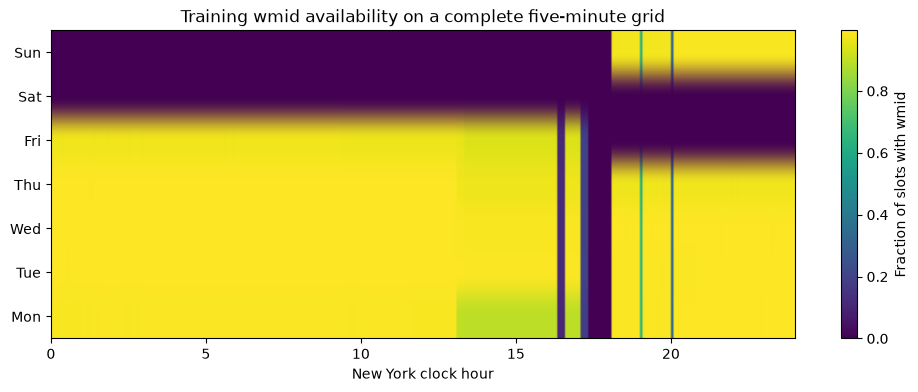

,Before close change,After close change,After pause removal
16:15,0.957528,0.956146,0.959731
16:20,0.000000,0.000000,0.959731
16:30,0.000000,0.000000,0.959731
16:35,0.957528,0.956146,0.959731
17:00,0.957528,0.956146,0.959731
17:05,0.957528,0.000000,0.000000
17:15,0.957528,0.000000,0.000000
17:20,0.000000,0.000000,0.000000
18:00,0.000000,0.000000,0.000000
18:05,0.788789,0.788704,0.792593


wmid_present,False,True
scheduled_trading_bar,,
False,40674,51
True,3107,596902


,session_diagnostics
training_rows,640734
scheduled_open_instants,600009
scheduled_trading_bars,600009
quotes_present,596953
missing_quotes_in_scheduled_bars,3107
quotes_outside_scheduled_bars,51


Dates with the most quotes outside the schedule (audit, not automatic relabeling):


,rows
2014-07-03,3
2014-11-28,3
2014-12-24,3
2015-11-27,3
2015-12-24,3
2016-11-25,3
2017-07-03,3
2017-11-24,3
2018-07-03,3
2018-11-23,3


SESSION_DIAGNOSTICS
training_rows                       640734
scheduled_open_instants             600009
scheduled_trading_bars              600009
quotes_present                      596953
missing_quotes_in_scheduled_bars      3107
quotes_outside_scheduled_bars           51
ERA_AVAILABILITY
       Before close change  After close change  After pause removal
16:15             0.957528            0.956146             0.959731
16:20             0.000000            0.000000             0.959731
16:30             0.000000            0.000000             0.959731
16:35             0.957528            0.956146             0.959731
17:00             0.957528            0.956146             0.959731
17:05             0.957528            0.000000             0.000000
17:15             0.957528            0.000000             0.000000
17:20             0.000000            0.000000             0.000000
18:00             0.000000            0.000000             0.000000
18:05             0.78878

In [4]:
from takehome.sessions import is_tradable as es_is_tradable, es_schedule, availability_by_week

weekly_availability = availability_by_week(df['wmid'])
weekly = weekly_availability['has_wmid'].unstack('weekday').reindex(columns=range(7))
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(weekly.T, aspect='auto', origin='lower', extent=(0, 24, -.5, 6.5))
ax.set_yticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax.set_xlabel('New York clock hour'); ax.set_title('Training wmid availability on a complete five-minute grid')
fig.colorbar(im, ax=ax, label='Fraction of slots with wmid'); plt.show(); plt.close('all')

# A single pooled weekly rule would hide historical changes.
era_profiles = {}
for name, start, end in [('Before close change', '2014-01-01', '2015-09-20'),
                          ('After close change', '2015-09-21', '2021-06-27'),
                          ('After pause removal', '2021-06-28', '2022-07-14')]:
    q = df.loc[start:end, 'wmid']
    p = availability_by_week(q)
    era_profiles[name] = p.loc[p.index.get_level_values('weekday') < 5, 'has_wmid'].groupby('minute').mean()
boundaries = [16*60+15,16*60+20,16*60+30,16*60+35,17*60,17*60+5,17*60+15,17*60+20,18*60,18*60+5,19*60,20*60]
era_availability = pd.DataFrame(era_profiles).reindex(boundaries)
era_availability.index = [f'{m//60:02d}:{m%60:02d}' for m in boundaries]
display(era_availability)

is_tradable = es_is_tradable(df.index)
is_trading_bar = es_is_tradable(df.index, bar_end=True)
quote_available = df['wmid'].notna()
display(pd.crosstab(is_trading_bar.rename('scheduled_trading_bar'), quote_available.rename('wmid_present')))
session_diagnostics = pd.Series({
    'training_rows': len(df), 'scheduled_open_instants': int(is_tradable.sum()),
    'scheduled_trading_bars': int(is_trading_bar.sum()), 'quotes_present': int(quote_available.sum()),
    'missing_quotes_in_scheduled_bars': int((is_trading_bar & ~quote_available).sum()),
    'quotes_outside_scheduled_bars': int((~is_trading_bar & quote_available).sum()),
}, name='session_diagnostics')
display(session_diagnostics.to_frame())
calendar_mismatches = df.loc[~is_trading_bar & quote_available, ['wmid']]
print('Dates with the most quotes outside the schedule (audit, not automatic relabeling):')
display(calendar_mismatches.groupby(calendar_mismatches.index.date).size().nlargest(12).to_frame('rows'))
print('SESSION_DIAGNOSTICS'); print(session_diagnostics.to_string())
print('ERA_AVAILABILITY'); print(era_availability.to_string())

### Calendar audit and use

The recurring isolated missing slot around 19:00 winter / 20:00 summer New York corresponds to midnight UTC and looks like a data-production artifact, not a CME maintenance interval. Do not train an exchange calendar by treating every recurring NaN as a market closure.

The mask is defined for later fitting/execution workflows and can be generated without future prices. Existing standalone P&Ls and the ad hoc combination below are deliberately **not silently filtered** by this newly introduced mask, so their definitions remain comparable. To impose trading restrictions later, apply the schedule at the trade-decision/label interval, with explicit bar-label and fill conventions. The calendar is a scheduled-open model, not a guarantee of executable liquidity.

## 1. Scatter matrix

Nine representative feature columns are shown for readability, using **all their training observations**. Missing pairs are omitted by the plotting routine; rows are not sampled. The all-feature correlation matrix below covers all feature pairs.

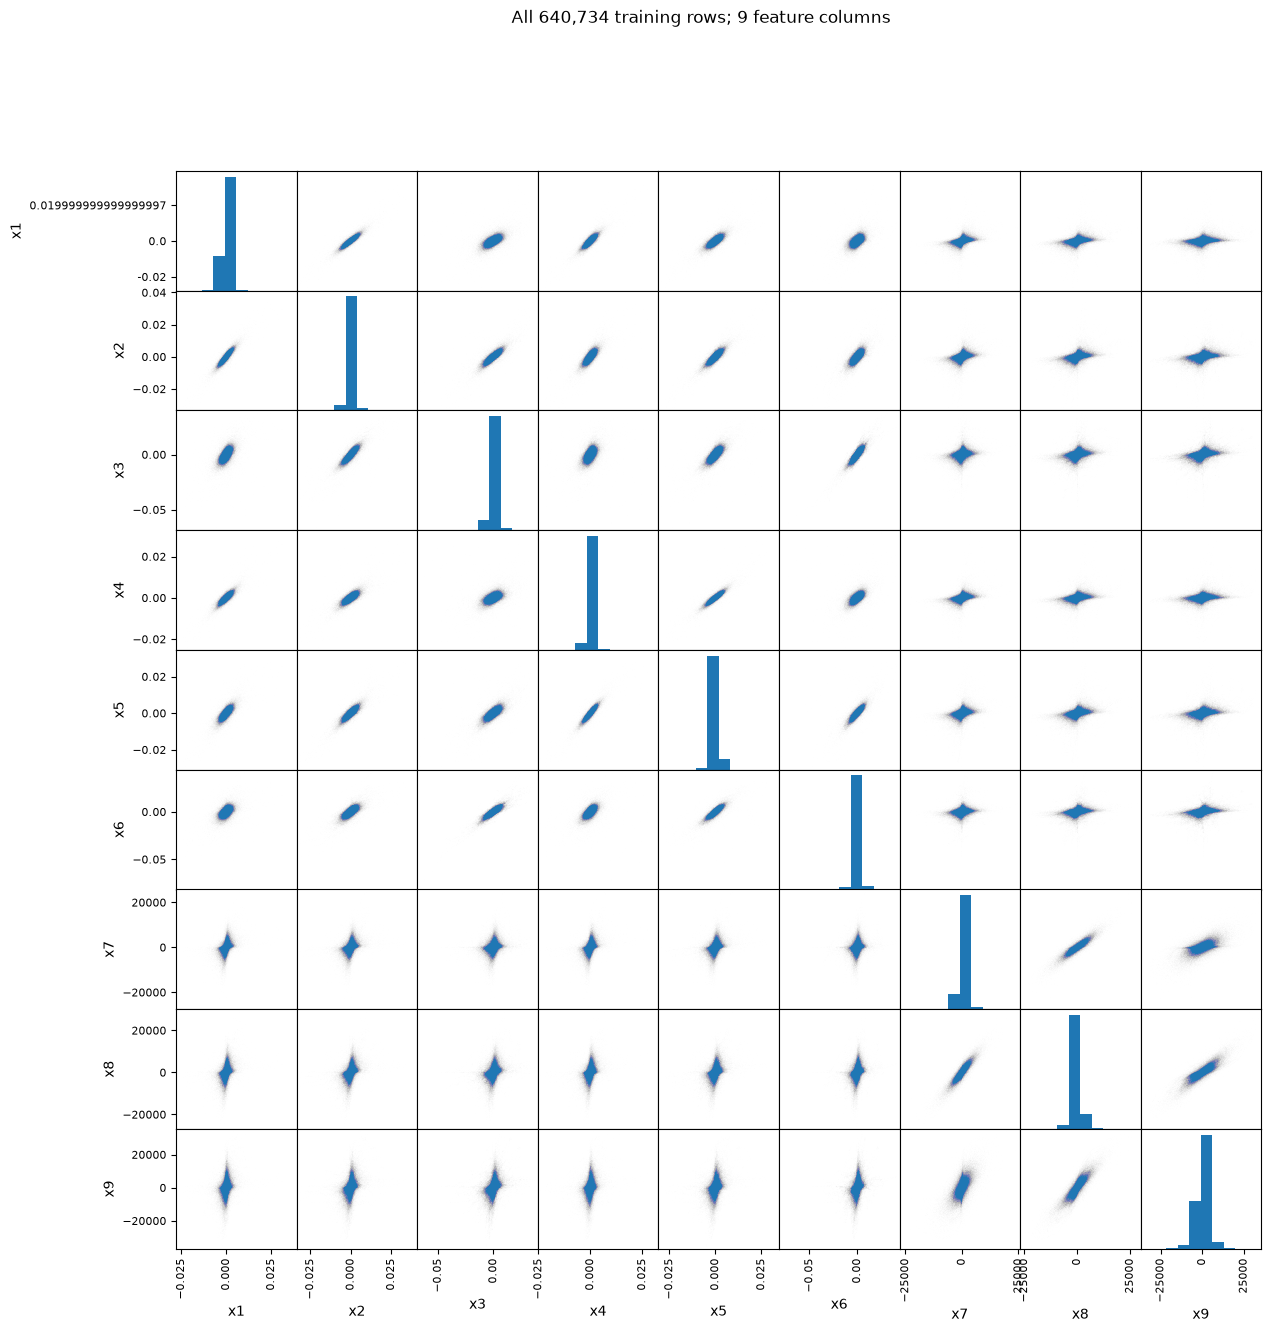

In [5]:
scatter_features = [c for c in feature_cols if df[c].nunique() > 1][:SCATTER_N_FEATURES]
scatter_matrix(df[scatter_features], figsize=(14, 14), diagonal='hist',
               alpha=.08, s=.2, rasterized=True)
plt.suptitle(f'All {len(df):,} training rows; {len(scatter_features)} feature columns', y=.995)
plt.show()
plt.close('all')

## 2. Distribution-shape screen and return sanity check

No Gaussianity test. The full-sample screen flags a dip statistic above 0.01, absolute Bowley quartile skew above 0.25, an exact point mass above 10%, or fewer than 20 unique values. These are practical degeneracy thresholds, not calibrated hypothesis tests; a pass does not prove a bell shape. High kurtosis is deliberately allowed.

Using the [Hartigan dip statistic](https://github.com/RUrlus/diptest) rather than its iid p-value avoids both a sample cap and interpreting tiny large-sample departures as useful rejections. Serially dependent features are not iid.

`adjMid.pct_change(fill_method=None)` is a contemporaneous sanity check. The supplied `ret_5m` is also reported separately; its alignment is not assumed to match that price change. All values and sample counts below are training-only.

,feature,n,nunique,max_mass,robust_skew,dip_stat,bell_like
6,x7,346261,345026,0.002940,0.065775,inf,False
68,x69,9126,9126,0.000110,-0.019220,0.002129,True
66,x67,9126,9126,0.000110,-0.012363,0.001646,True
67,x68,9126,9126,0.000110,-0.059021,0.001637,True
11,x12,16560,16560,0.000060,-0.036038,0.001600,True
...,...,...,...,...,...,...,...
56,x57,480744,480744,0.000002,-0.010753,0.000172,True
58,x59,338841,338841,0.000003,0.024714,0.000165,True
40,x41,446749,446749,0.000002,-0.029800,0.000164,True
54,x55,480744,480744,0.000002,0.037573,0.000145,True


Pass shape screen: 99/100; flagged: 1


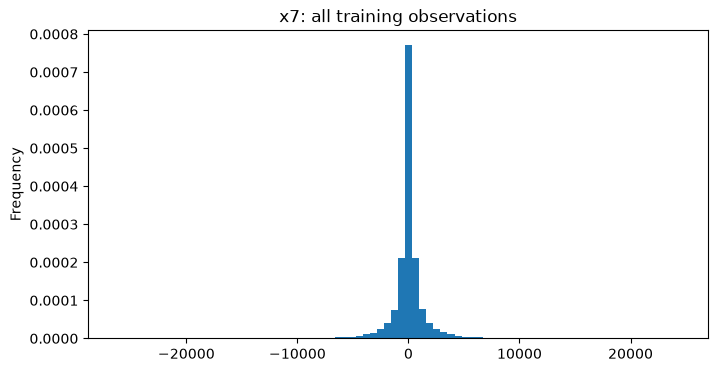

,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
60,x61,0.415557,0.000000e+00,0.350083,0.000000e+00,168937,0.000000e+00,0.000000e+00,0.415557
57,x58,-0.411100,0.000000e+00,-0.337529,0.000000e+00,338832,0.000000e+00,0.000000e+00,0.411100
42,x43,0.381231,0.000000e+00,0.313393,0.000000e+00,168935,0.000000e+00,0.000000e+00,0.381231
36,x37,0.351904,0.000000e+00,0.295867,0.000000e+00,168823,0.000000e+00,0.000000e+00,0.351904
45,x46,0.345192,0.000000e+00,0.282360,0.000000e+00,99355,0.000000e+00,0.000000e+00,0.345192
99,x100,0.077271,0.000000e+00,0.337293,0.000000e+00,584307,0.000000e+00,0.000000e+00,0.337293
33,x34,0.332063,0.000000e+00,0.264749,0.000000e+00,161112,0.000000e+00,0.000000e+00,0.332063
9,x10,0.286760,6.345562e-311,0.328594,0.000000e+00,16560,1.379470e-310,0.000000e+00,0.328594
66,x67,0.321950,4.098448e-219,0.314194,3.150248e-208,9126,7.881631e-219,6.429077e-208,0.321950
51,x52,0.319535,0.000000e+00,0.285254,0.000000e+00,167411,0.000000e+00,0.000000e+00,0.319535


Top correlations to supplied ret_5m (not assumed contemporaneous):


,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
57,x58,0.018288,1.831179e-26,0.025212,9.105777e-49,338777,1.831179e-24,9.105777e-47,0.025212
6,x7,-0.001722,3.108236e-01,-0.023301,8.598336e-43,346205,4.257858e-01,2.149584e-41,0.023301
9,x10,-0.007924,3.078746e-01,-0.021978,4.678876e-03,16560,4.257858e-01,8.507047e-03,0.021978
39,x40,-0.001265,3.978454e-01,-0.021057,5.449059e-45,446673,5.113141e-01,1.816353e-43,0.021057
33,x34,-0.020514,1.799257e-16,-0.016435,4.186711e-11,161114,5.997525e-15,2.462771e-10,0.020514
54,x55,-0.000528,7.141038e-01,-0.020364,2.843706e-45,480723,7.761998e-01,1.421853e-43,0.020364
12,x13,-0.003123,2.229217e-01,-0.019904,7.865186e-15,152348,3.483151e-01,7.048631e-14,0.019904
15,x16,-0.002247,3.805279e-01,-0.019792,1.111916e-14,152348,5.006947e-01,8.553199e-14,0.019792
60,x61,-0.018851,9.356760e-15,-0.018883,8.458357e-15,168885,1.871352e-13,7.048631e-14,0.018883
34,x35,-0.018762,5.022619e-14,-0.007524,2.527138e-03,161114,8.371031e-13,4.768185e-03,0.018762


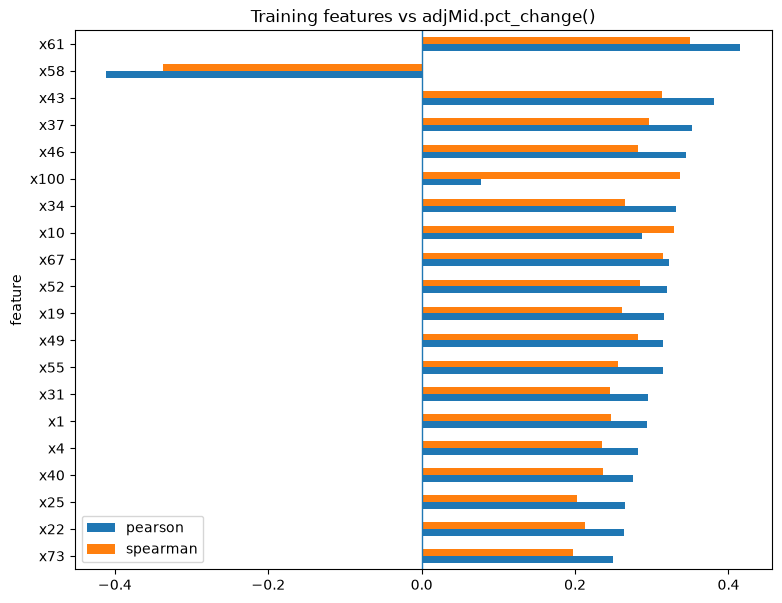

In [6]:
shape = bell_shape_table(df, feature_cols)
flagged_shape = shape.loc[~shape.bell_like]
display(shape)
print(f'Pass shape screen: {shape.bell_like.sum()}/{len(shape)}; flagged: {len(flagged_shape)}')
assert shape.set_index('feature')['n'].reindex(feature_cols).eq(df[feature_cols].count()).all()
for col in flagged_shape.feature.head(6):
    df[col].plot.hist(bins=80, density=True, figsize=(8, 4), title=f'{col}: all training observations')
    plt.show()
    plt.close('all')

df['_ret1'] = df.adjMid.pct_change(fill_method=None)
return_corr = correlation_to_column(df, '_ret1', feature_cols)
provided_corr = correlation_to_column(df, 'ret_5m', feature_cols)
strong_target = return_corr.loc[return_corr.max_abs_corr >= .10]
display(strong_target)
print('Top correlations to supplied ret_5m (not assumed contemporaneous):')
display(provided_corr.head(15))
return_corr.head(20).sort_values('max_abs_corr').plot.barh(
    x='feature', y=['pearson', 'spearman'], figsize=(9, 7),
    title='Training features vs adjMid.pct_change()')
plt.axvline(0, linewidth=1)
plt.show()
plt.close('all')

## 3. Feature correlation and dendrogram

Cluster using distance $1-|\rho_S|$ so strongly positive and strongly negative variants are grouped together. The heatmap retains signed Spearman correlation.

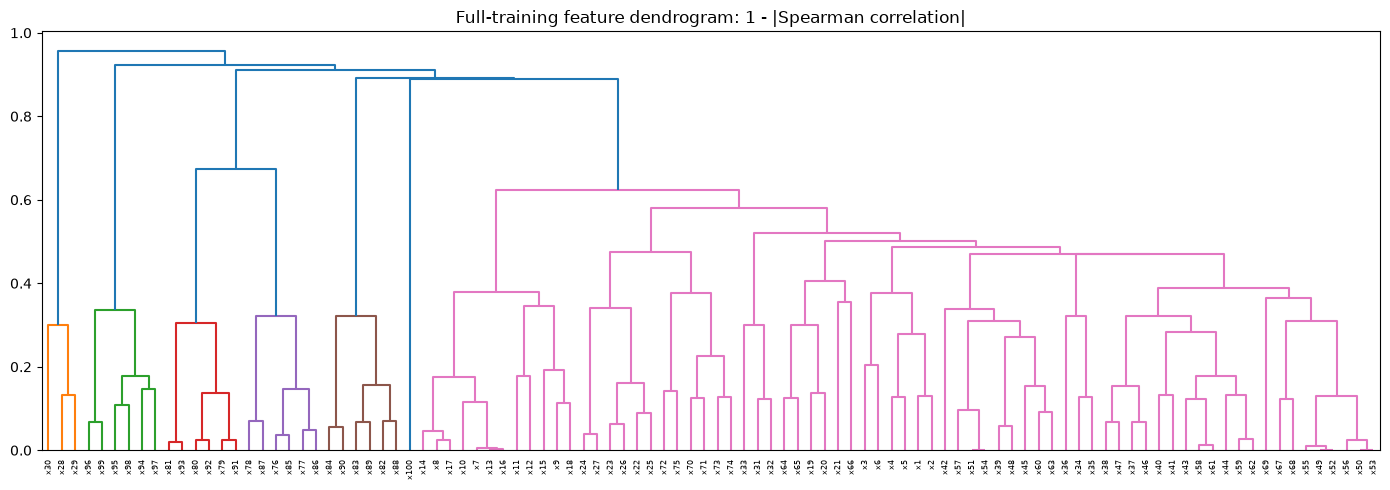

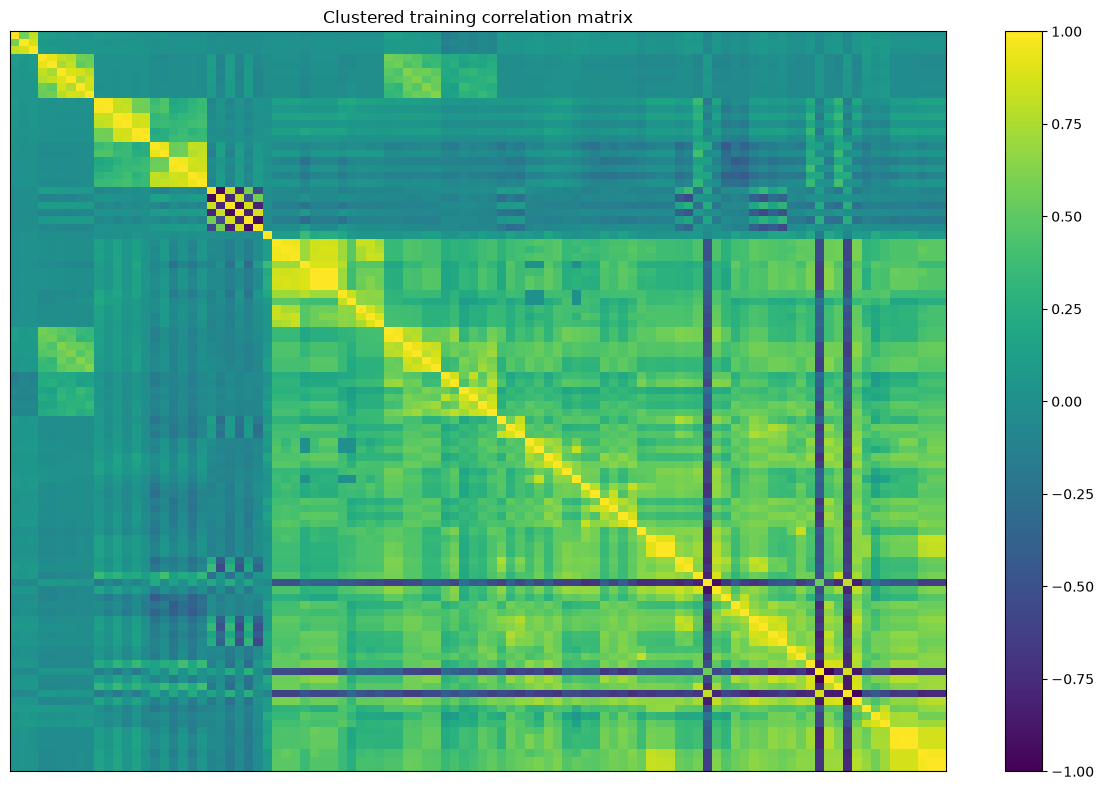

,feature1,feature2,corr,abs_corr,index_gap
0,x49,x52,0.999996,0.999996,3
1,x50,x53,0.999857,0.999857,3
2,x51,x54,0.999642,0.999642,3
3,x13,x16,0.997249,0.997249,3
4,x7,x16,0.994874,0.994874,9
5,x7,x13,0.994009,0.994009,6
6,x49,x55,0.988759,0.988759,6
7,x52,x55,0.988740,0.988740,3
8,x58,x61,-0.987044,0.987044,3
9,x81,x93,0.981349,0.981349,12


,n_pairs,median_abs_corr,p90_abs_corr,frac_gt_080
index_gap,,,,
1,99,0.818790,0.872724,0.636364
3,97,0.629066,0.940188,0.226804
2,98,0.558137,0.766949,0.071429
6,94,0.491680,0.841372,0.106383
30,70,0.482820,0.578557,0.000000
12,88,0.477858,0.717065,0.034091
9,91,0.471795,0.782792,0.098901
21,79,0.459784,0.630910,0.037975
33,67,0.453791,0.604650,0.000000


,count,mean,median
same_mod3,,,
False,3333,0.279061,0.276361
True,1617,0.340687,0.369206


In [7]:
corr, z, order = correlation_clustering(df, feature_cols, method='spearman')
plt.figure(figsize=(14, 5))
dendrogram(z, labels=feature_cols, leaf_rotation=90, leaf_font_size=6)
plt.title('Full-training feature dendrogram: 1 - |Spearman correlation|')
plt.tight_layout()
plt.show()
plt.close('all')
heatmap(corr.loc[order, order], 'Clustered training correlation matrix', labels=False, limits=(-1, 1))
plt.close('all')
upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs = redundant_pairs(corr, threshold=.8)
display(pairs.head(30))
gap_pairs = pairs.dropna(subset=['index_gap']).copy()
gap_pairs['index_gap'] = gap_pairs.index_gap.astype(int)
all_pairs = redundant_pairs(corr, threshold=0).dropna(subset=['index_gap'])
all_pairs['index_gap'] = all_pairs.index_gap.astype(int)
gap_summary = all_pairs.groupby('index_gap').agg(
    n_pairs=('abs_corr', 'size'), median_abs_corr=('abs_corr', 'median'),
    p90_abs_corr=('abs_corr', lambda x: x.quantile(.9)),
    frac_gt_080=('abs_corr', lambda x: (x >= .8).mean()),
).sort_values('median_abs_corr', ascending=False)
all_pairs['same_mod3'] = all_pairs.index_gap.mod(3).eq(0)
mod3_summary = all_pairs.groupby('same_mod3').abs_corr.agg(['count', 'mean', 'median'])
display(gap_summary.head(20), mod3_summary)

## 4. Full-training autocorrelation

Ljung–Box(15) is applied directly to each feature, not regression residuals. Display and rank raw statistics, ACF(1), and per-feature observation counts; Q also grows with sample size. Missing values are omitted per feature: these are lags between successive observed values, not guaranteed five-minute clock intervals.

,feature,n,acf1,max_abs_acf_1_to_lag,lb_stat,lb_pvalue,lb_qvalue
56,x57,480744,0.989220,0.989220,4.578699e+06,0.0,0.0
41,x42,446749,0.989065,0.989065,4.307341e+06,0.0,0.0
65,x66,374281,0.988780,0.988780,3.650854e+06,0.0,0.0
77,x78,338776,0.990617,0.990617,3.395004e+06,0.0,0.0
5,x6,329833,0.987226,0.987226,3.214314e+06,0.0,0.0
2,x3,333875,0.987453,0.987453,3.203368e+06,0.0,0.0
59,x60,338841,0.986322,0.986322,3.135615e+06,0.0,0.0
8,x9,346261,0.976988,0.976988,2.935727e+06,0.0,0.0
55,x56,480744,0.963029,0.963029,2.612777e+06,0.0,0.0
40,x41,446749,0.963445,0.963445,2.431948e+06,0.0,0.0


Usable features: 100/100
Ljung-Box(15), FDR q<5%: 100/100


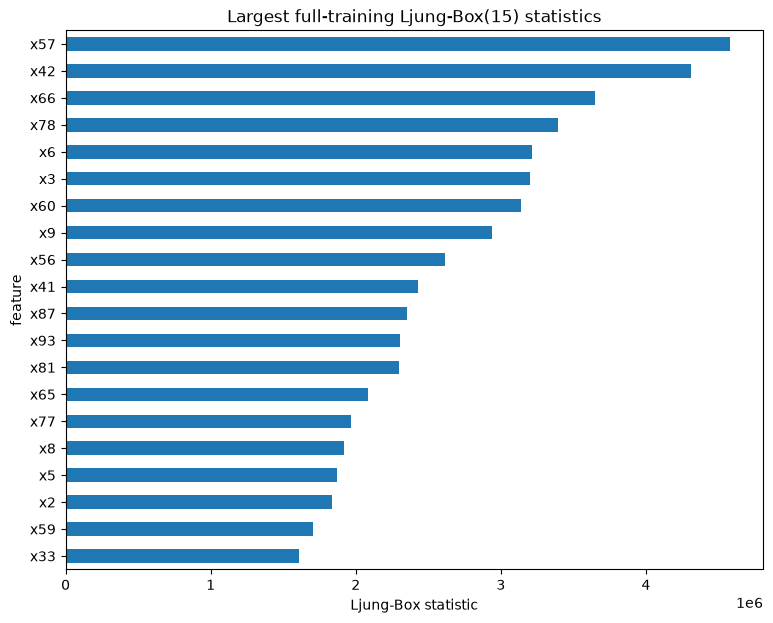

In [8]:
auto = autocorrelation_table(df, feature_cols, lag=ACF_LAG)
assert auto.set_index('feature')['n'].reindex(feature_cols).eq(df[feature_cols].count()).all()
display(auto.head(20))
print(f'Usable features: {auto.lb_stat.notna().sum()}/{len(auto)}')
print(f'Ljung-Box({ACF_LAG}), FDR q<5%: {(auto.lb_qvalue < .05).sum()}/{len(auto)}')
auto.head(20).sort_values('lb_stat').plot.barh(
    x='feature', y='lb_stat', figsize=(9, 7), legend=False,
    title=f'Largest full-training Ljung-Box({ACF_LAG}) statistics')
plt.xlabel('Ljung-Box statistic')
plt.show()
plt.close('all')

### 4.1 Longer-lag / seasonal ACF patterns

Repeated bands or peaks in the heatmap flag periodic structure. These are **row lags**: if source bars have gaps, lag 288 is not automatically a 24-hour clock-time lag.

,peak_lag,peak_acf
x30,16,0.624285
x18,16,0.618594
x78,16,0.607077
x87,16,0.605638
x33,16,0.591339
x6,16,0.591328
x84,16,0.589893
x93,16,0.589365
x66,16,0.588983
x81,16,0.585701


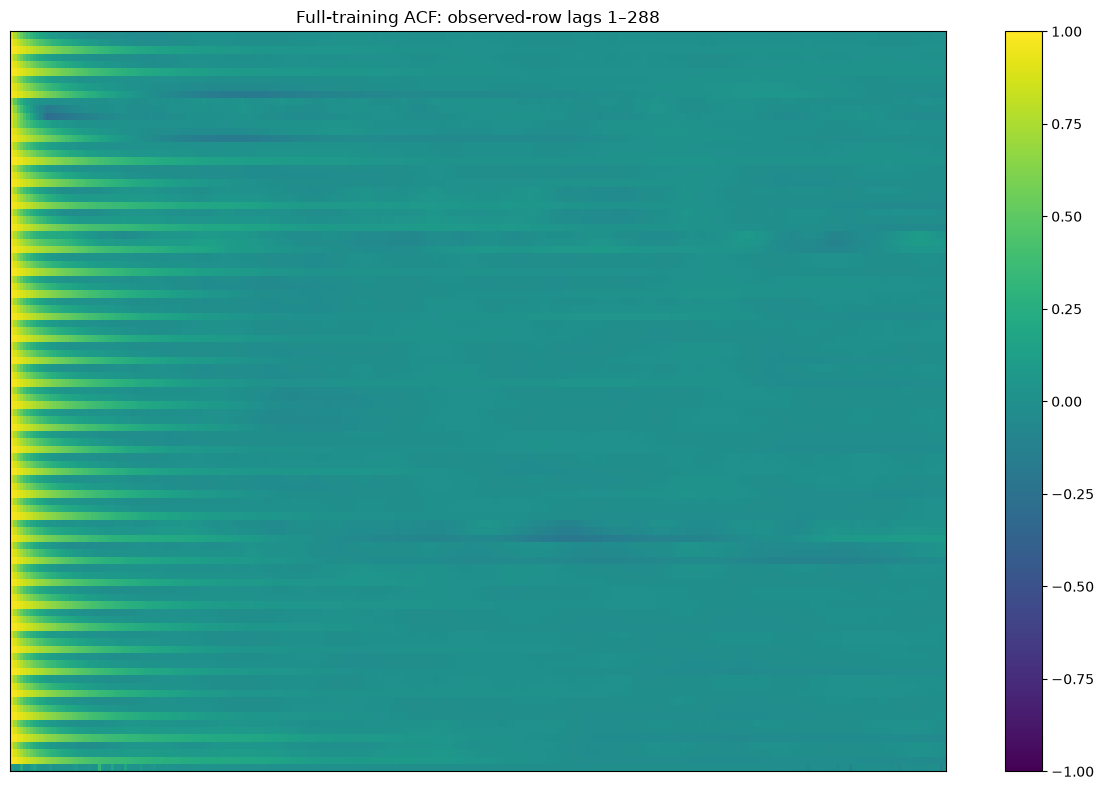

In [9]:
season_acf = acf_matrix(df, feature_cols, nlags=SEASONAL_NLAGS)
long_lag = season_acf.loc[ACF_LAG + 1:]
valid = long_lag.columns[long_lag.notna().any()]
peak_lag = long_lag[valid].abs().idxmax()
peak = pd.DataFrame({
    'peak_lag': peak_lag,
    'peak_acf': [long_lag.loc[peak_lag[c], c] for c in valid],
}).sort_values('peak_acf', key=lambda s: s.abs(), ascending=False)
display(peak.head(20))
heatmap(season_acf.loc[1:].T, 'Full-training ACF: observed-row lags 1–288', labels=False, limits=(-1, 1))
plt.close('all')

## 5. Training-period distribution shifts

Adjacent-month mean changes are scaled by the **training** standard deviation. The log standard-deviation ratio compares adjacent months. These are descriptive changes, not formal break-date estimates. All grouping now uses `msgStamp`; partial boundary months can have fewer observations.

,max_abs_monthly_mean_shift_z,max_abs_monthly_log_std_ratio
x27,1.194728,1.544659
x24,1.163821,1.561496
x99,1.127276,1.652901
x96,1.091659,1.706036
x30,1.075000,2.899247
x33,1.064781,1.325685
x39,1.005112,1.154962
x63,0.966948,1.200168
x36,0.896158,1.049421
x29,0.888844,2.891253


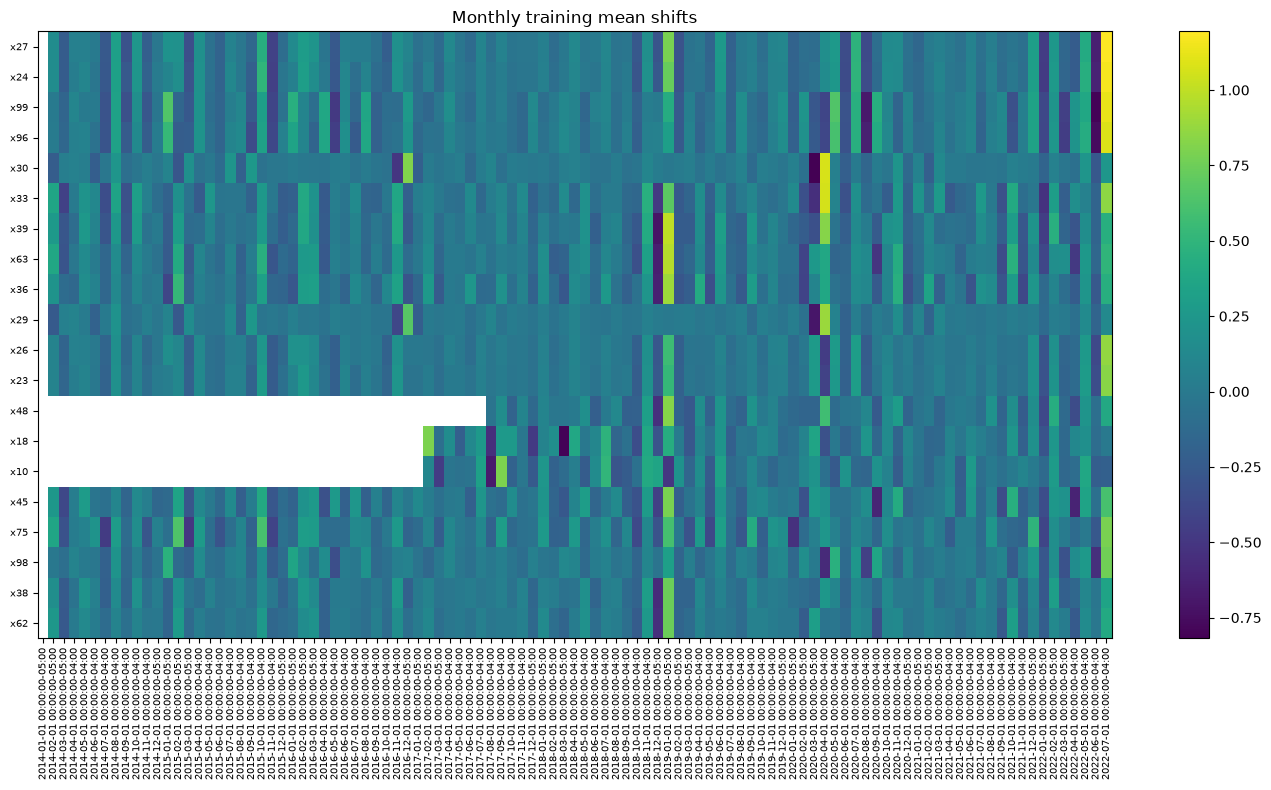

In [10]:
mean_shift, vol_shift = monthly_shift_scores(df.reset_index(), 'msgStamp', feature_cols)
breaks = pd.DataFrame({
    'max_abs_monthly_mean_shift_z': mean_shift.abs().max(),
    'max_abs_monthly_log_std_ratio': vol_shift.abs().max(),
}).sort_values('max_abs_monthly_mean_shift_z', ascending=False)
display(breaks.head(20))
heatmap(mean_shift[breaks.head(20).index].T, 'Monthly training mean shifts', figsize=(14, 8))
plt.close('all')

## 6. Cashflow: infer the definition from named fields

Only named numeric market variables are compared; `x*` features are deliberately excluded. Examine cashflow relative to volume as well as unconditional level correlations.

,wmid,adjMid,volume,cashflow,ret_5m
wmid,1.000000,0.999182,0.052109,0.008949,0.002637
adjMid,0.999182,1.000000,0.054724,0.008655,0.002669
volume,0.052109,0.054724,1.000000,-0.013539,0.008276
cashflow,0.008949,0.008655,-0.013539,1.000000,-0.016442
ret_5m,0.002637,0.002669,0.008276,-0.016442,1.000000


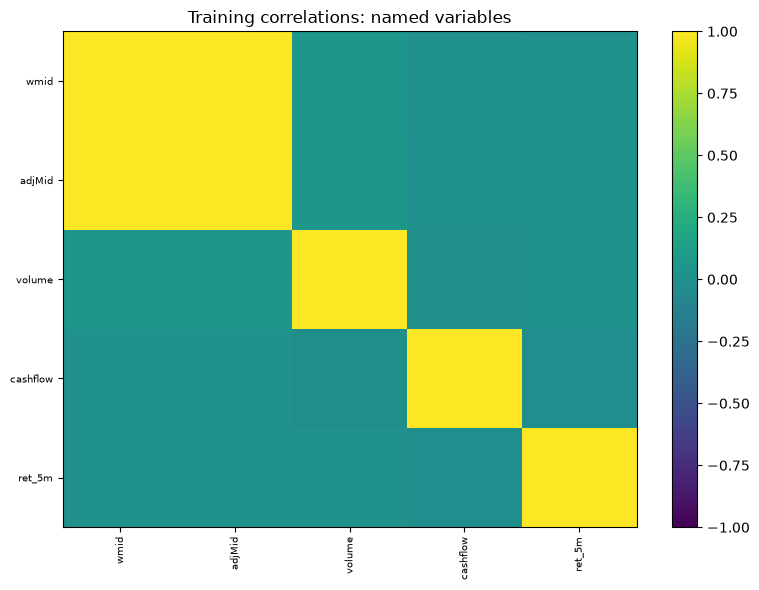

,spearman
adjMid,0.008655
wmid,0.008949
volume,-0.013539
ret_5m,-0.016442


In [11]:
named_numeric = [c for c in df.select_dtypes(include=np.number).columns
                 if c not in feature_cols and not c.startswith('_')]
named_corr = df[named_numeric].corr(method='spearman')
display(named_corr)
heatmap(named_corr, 'Training correlations: named variables', figsize=(8, 6), limits=(-1, 1))
plt.close('all')
cash_named = named_corr['cashflow'].drop('cashflow').sort_values(key=lambda x: x.abs()).to_frame('spearman')
display(cash_named)

### Cashflow-to-volume exceptions

Show rows where `abs(cashflow / volume) > 1`. Zero volume is not silently discarded: nonzero cashflow divided by zero appears as infinity and is included by this predicate. Display a deterministic sample of at most 20 rows, followed by all distinct dates and their exception counts. Only the display is sampled; the predicate and counts use every training row. No CSV is exported.

In [12]:
flow_ratio = df.cashflow / df.volume
cashflow_outliers = df.loc[flow_ratio.abs().gt(1), named_numeric].assign(cashflow_per_volume=flow_ratio)
print(f'{len(cashflow_outliers):,} / {len(df):,} training rows have |cashflow / volume| > 1')
print(f'Zero-volume rows: {df.volume.eq(0).sum():,}')
display(cashflow_outliers.sample(n=min(20, len(cashflow_outliers)), random_state=0).sort_index())
exception_dates = cashflow_outliers.groupby(cashflow_outliers.index.date).size().rename('exception_rows')
print(f'{len(exception_dates)} unique local dates; counts below cover ALL exceptions, not the sample.')
with pd.option_context('display.max_rows', None):
    display(exception_dates.to_frame())

551 / 640,734 training rows have |cashflow / volume| > 1
Zero-volume rows: 6,471


,wmid,adjMid,volume,cashflow,ret_5m,cashflow_per_volume
msgStamp,,,,,,
2014-06-17 16:50:00-04:00,1934.220064,2130.867951,27.0,-67.0,0.000000,-2.481481
2014-09-15 02:25:00-04:00,1970.387755,2179.424142,56.0,-73.0,0.000254,-1.303571
2014-09-16 22:55:00-04:00,1990.565287,2201.824010,112.0,-119.0,-0.000126,-1.062500
2014-09-17 01:20:00-04:00,1990.176295,2201.547468,12.0,17.0,-0.000126,1.416667
2014-09-17 23:55:00-04:00,1994.661082,2206.525217,38.0,39.0,-0.000125,1.026316
2015-06-16 19:15:00-04:00,2089.641304,2337.265800,50.0,-55.0,-0.000120,-1.100000
2016-12-14 01:40:00-05:00,2266.662963,2595.787951,34.0,-78.0,-0.000110,-2.294118
2017-06-15 01:25:00-04:00,2430.087766,2788.970317,92.0,-105.0,-0.000206,-1.141304
2018-09-18 00:35:00-04:00,2893.045918,3303.185874,140.0,148.0,0.000173,1.057143


92 unique local dates; counts below cover ALL exceptions, not the sample.


,exception_rows
2014-03-17,4
2014-03-18,4
2014-03-19,2
2014-03-20,1
2014-03-21,2
2014-06-15,4
2014-06-16,15
2014-06-17,10
2014-06-18,5
2014-06-19,5


## Transform experiments

The following backtests share the same declared `SIGNAL_RULE`, all research rows and the existing daily aggregation convention. We first compare raw signals and time-of-day scaling, then raw pair products/residuals, and finally a one-row oracle and causal alpha-forecast controls. Keeping these related experiments together separates descriptive feature research from the later joint Ridge/Lasso validation.

Parameters are predeclared, not picked to maximize these plots. Products and directed residuals use every pair in small column batches. No displayed P&L is clipped: the **exposure** is bounded before multiplication by returns. Coverage and the maximum exposure are retained for each candidate, so the absence of numerical explosions can be checked rather than inferred from a rescaled axis.


### Signed-flow diagnostic, with the shared signal-only sizing

Cashflow may represent signed trade flow or imbalance rather than unsigned price-times-volume; its definition is not documented here. Out-of-range `cashflow/volume` can also reflect aggregation, unit or timestamp mismatches.

For this descriptive control only, clip that ratio to [-1,1], then apply the **same lagged, floored, capped signal normalizer** as every other main backtest. Unlike the old flow curve, no realized-return volatility enters its sizing. The un-clipped ratio remains x100 in the model. Return timing and execution assumptions still require verification.


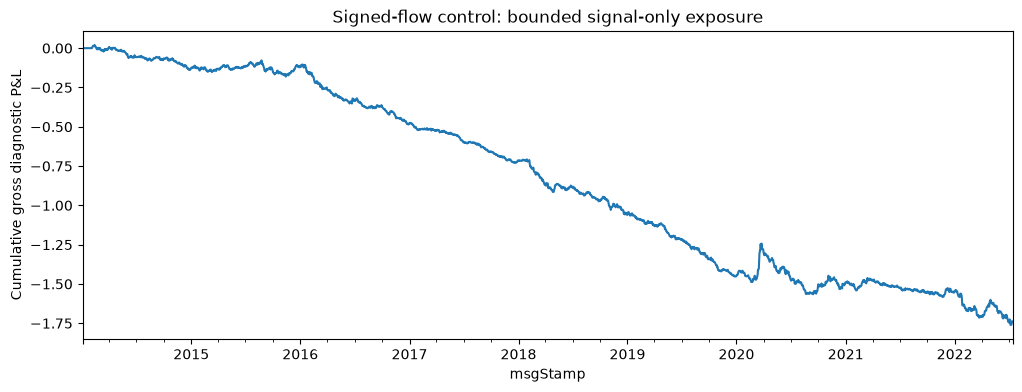

In [13]:
from takehome.features import backtest
flow_signal = df.cashflow.div(df.volume.replace(0, np.nan)).clip(-1, 1)
flow_contribution = backtest(flow_signal, df.ret_5m, HL, normalization=SIGNAL_RULE)
flow_cumulative = flow_contribution.resample('D').sum().cumsum()
flow_cumulative.plot(figsize=(12,4), title='Signed-flow control: bounded signal-only exposure')
plt.ylabel('Cumulative gross diagnostic P&L'); plt.show(); plt.close('all')


### Standalone feature importance

Each raw signal is evaluated independently with `SIGNAL_RULE`: lagged signal standard deviation, a past-only floor, and an explicit absolute exposure cap of 3. These are **standalone research diagnostics**, not incremental feature importance or an executable net-return backtest. No sign is chosen by looking at full-period outcomes.

All 100 x columns and every research row are used, in eight-column batches. The family panel includes a gross-normalized, one-row-lagged EWM-Sharpe combination. Its own right-hand axis has an independent scale. Raw-family meta scores are clipped below at zero; transformed families retain signed scores. Daily histograms report unannualized calendar-day mean/std. Warm-up and differing coverage are reported, not silently filled with tradable predictions.


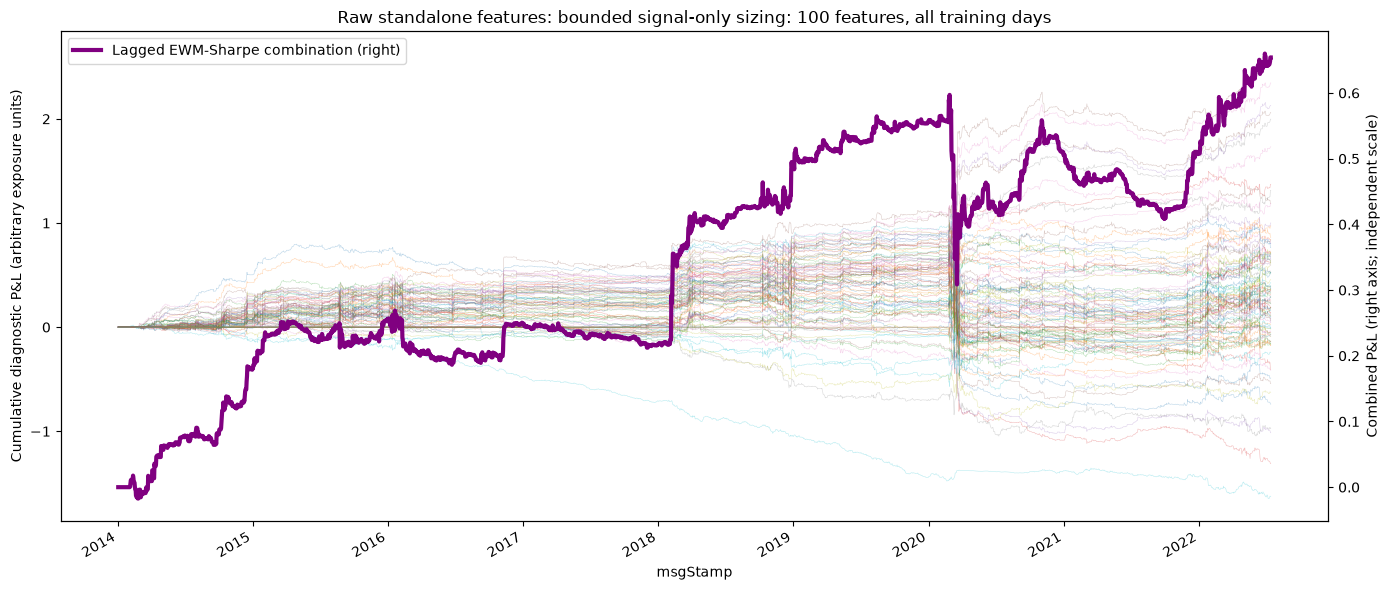

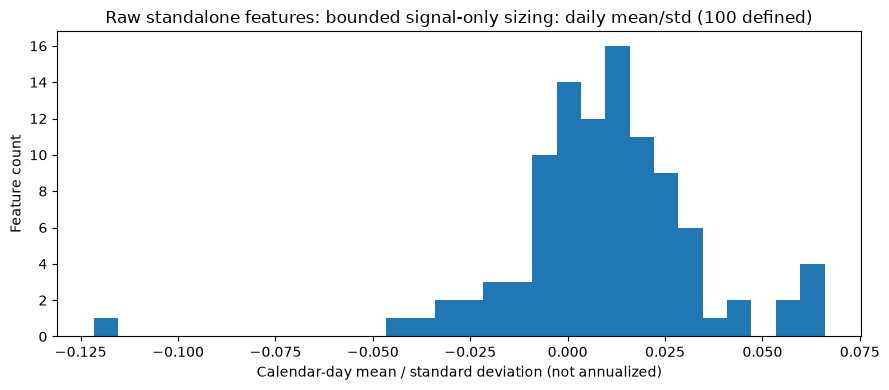

x1      0.022450
x2      0.026244
x3      0.020703
x4     -0.010983
x5      0.001387
          ...   
x96     0.028727
x97     0.042411
x98     0.024687
x99     0.024649
x100   -0.121648
Length: 100, dtype: float64

In [14]:
from functools import partial
from takehome import features as feature_ops
from takehome.features import ts_std, ts_standardize, ts_zscore, sharpe, combine_pnls
from takehome.plots import display_results
# Explicit notebook policy; no global monkey-patching of feature helpers.
evaluate_features = partial(feature_ops.evaluate_features, normalization=SIGNAL_RULE)
raw_blocks = (df[x_cols[j:j+BATCH_SIZE]] for j in range(0, len(x_cols), BATCH_SIZE))
pnl_daily, standalone, raw_meta = evaluate_features(
    raw_blocks, df.ret_5m, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
assert standalone.max_abs_weight.max() <= SIGNAL_RULE['cap']
display_results(pnl_daily, 'Raw standalone features: bounded signal-only sizing',
                meta_daily=raw_meta.resample('D').sum())


In [15]:
with pd.option_context('display.max_rows', None):
    display(standalone)
print('Standalone daily mean/std range:', standalone.daily_mean_over_std.min(), standalone.daily_mean_over_std.max())
print('Largest raw-feature exposure:', standalone.max_abs_weight.max())


,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x76,0.065944,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.000000,0.019055
x85,0.062096,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.018704
x86,0.062035,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.017966
x77,0.061200,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.000000,0.018757
x87,0.059069,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.015948
x78,0.057041,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.000000,0.016951
x94,0.046554,153522,2064,2014-04-29 12:20:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.017548
x97,0.042411,147765,2058,2014-05-07 12:00:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.018387
x58,0.037774,332731,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.000000,0.019297
x95,0.034551,153522,2064,2014-04-29 12:20:00-04:00,2022-07-13 16:00:00-04:00,3.000000,0.018284


Standalone daily mean/std range: -0.1216482783790075 0.06594448917792016
Largest raw-feature exposure: 3.0


### Forecasts, positions and evaluation have different units

A return forecast is not a position. The old inverse-variance rule turned a smaller-magnitude forecast into a larger position: replacing $s$ by $cs$ divides $s/\sigma_s^2$ by $c$. The fixed first-scale multiplier used in the normalization control removes this dependence on measurement units, but leaves that individual curve's jump concentration unchanged.

The selected position rule instead uses one power of signal standard deviation, an anchored floor and a visible cap. It needs no prices during the final blackout and keeps signs without demeaning the signal. This is **signal standardization**, not asset-volatility targeting. Model training weights are a separate decision; weighted residual fitting does not automatically create these positions.


In [16]:
from time import perf_counter
from takehome.features import dszl, pairwise_features, combine_pnls
raw_features = df[x_cols]
experiment_seconds = {}
assert raw_features.index.equals(df.index) and df.index.max() < split['cutoff']


### Time-of-day standardization — dszl(hl=10)

Apply `ts_standardize` **inside each local clock-time group**, then restore chronological order. There is no demeaning. Ten observations means ten nonzero observations at that clock time, not ten adjacent bars. The current feature value is known and included in its scale; no target enters the transform.

The displayed family strategies subsequently use the same 6,048-observation signal-only exposure rule. For the joint model later, the input concatenates **the raw features and these dszl features**, not their positions or P&Ls. Its group state continues across train/forecast boundaries and throughout the label blackout; it is never refitted on future labels. Only after transformation are undefined model inputs zero-imputed.


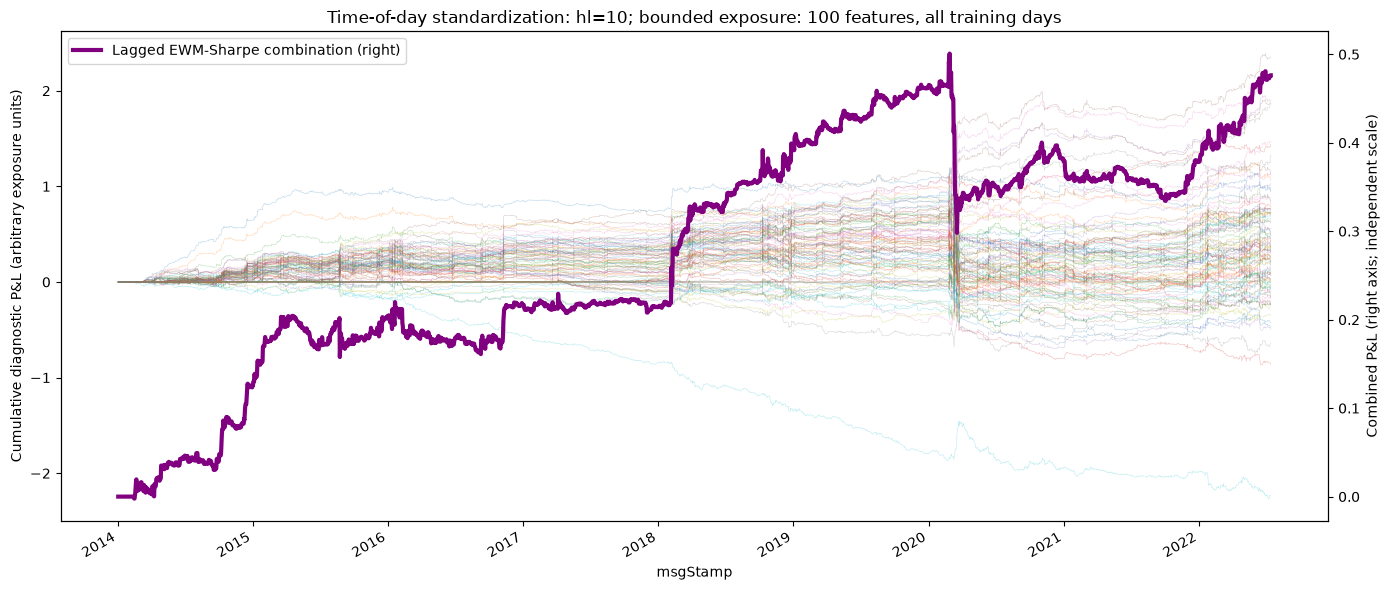

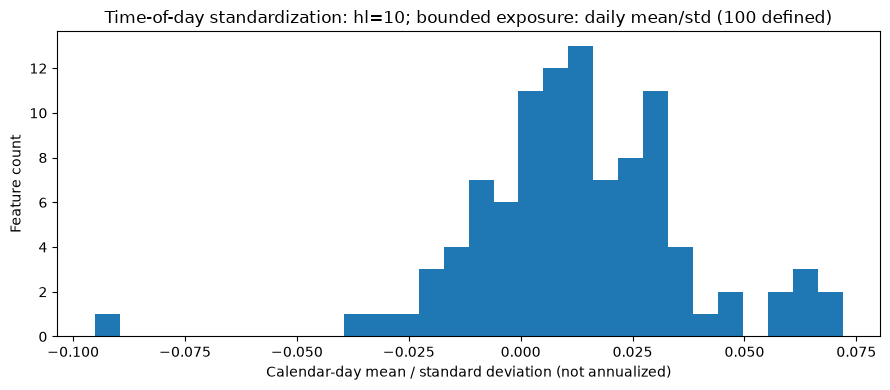

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x76,0.071931,331262,2154,2014-03-11 14:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.005629
x77,0.069463,331262,2154,2014-03-11 14:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.005514
x86,0.066129,227903,2136,2014-04-04 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.004992
x85,0.066003,227903,2136,2014-04-04 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.005097
x78,0.064304,331262,2154,2014-03-11 14:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.004968
x94,0.058437,152820,2055,2014-05-12 14:50:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.006969
x87,0.056869,227903,2136,2014-04-04 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.004049
x97,0.048970,147063,2047,2014-05-22 10:45:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.007684
x58,0.045351,331327,2154,2014-03-11 14:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.008703
x95,0.043325,152820,2055,2014-05-12 14:50:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.006086


In [17]:
started = perf_counter()
dszl_blocks = (dszl(raw_features.iloc[:, j:j+BATCH_SIZE], hl=DSZL_HL)
               for j in range(0, len(x_cols), BATCH_SIZE))
dszl_daily, dszl_summary, dszl_meta = evaluate_features(
    dszl_blocks, df.ret_5m, hl=HL, meta=True, meta_hl=META_HL)
experiment_seconds['dszl(10)'] = perf_counter() - started
assert dszl_daily.shape[1] == len(x_cols) and dszl_summary.max_abs_weight.max() <= SIGNAL_RULE['cap']
display_results(dszl_daily, 'Time-of-day standardization: hl=10; bounded exposure',
                meta_daily=dszl_meta.resample('D').sum())
display(dszl_summary.head(10))


### Two-way interactions — products of distinct raw features

Use $z_{ij,t}=x_{i,t}x_{j,t}$ for every $i<j$: **4,950 products** for 100 predictors. Squares and duplicate reverse-order products are excluded. These are raw products, not products of the dszl signals and not demeaned products. Missing either input makes the product missing. The following P&L scaling uses the **product's own** lagged EWM standard deviation, floor and cap.

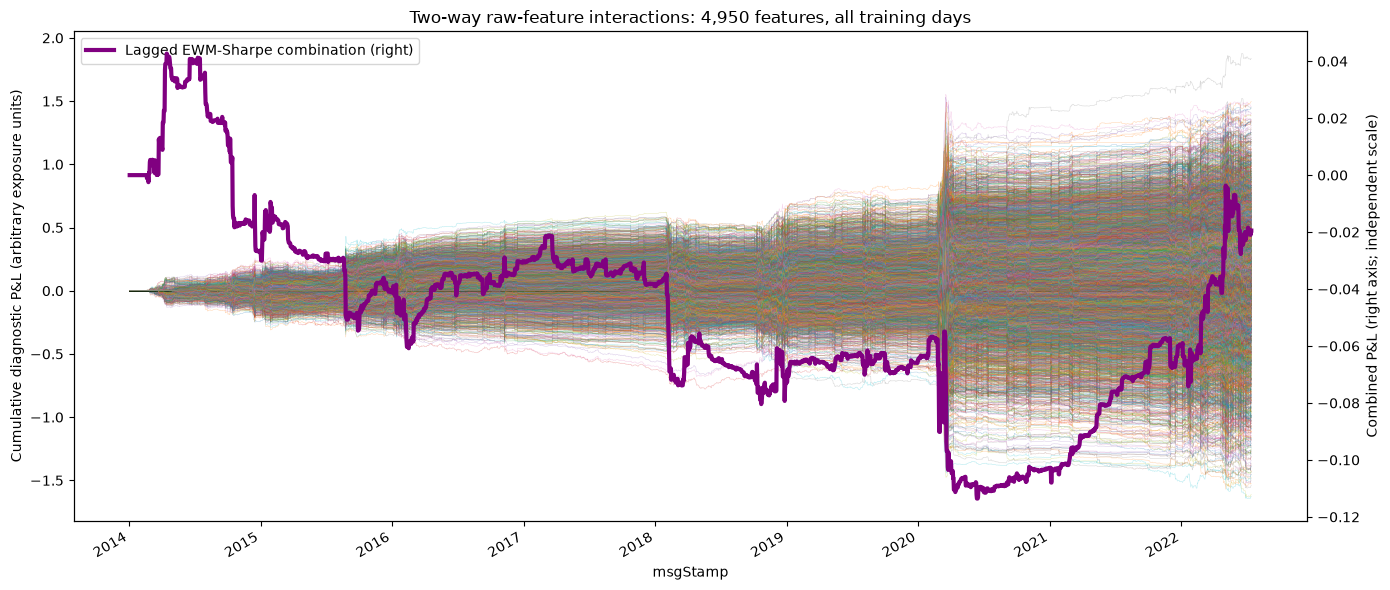

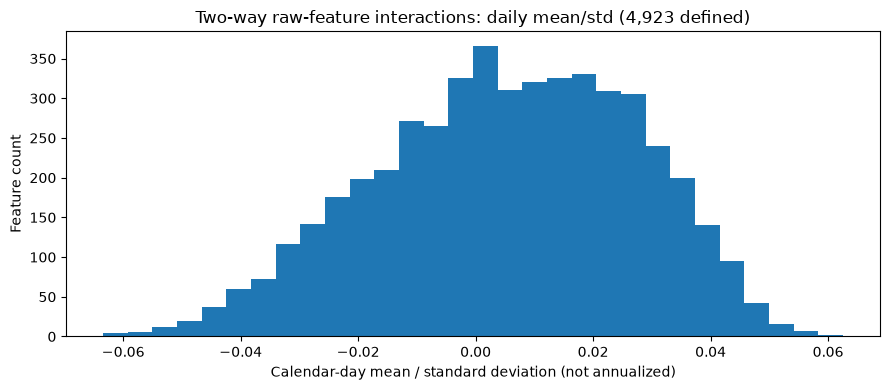

Top 10 of all distinct products; this is a training screen, not feature selection.


,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x39*x72,0.062537,149408,2058,2014-05-07 12:35:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.022683
x60*x78,0.058728,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.017432
x33*x72,0.057276,148950,2058,2014-05-07 15:25:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.020638
x54*x72,0.056794,148960,2054,2014-05-07 12:35:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.021563
x51*x72,0.056200,148960,2054,2014-05-07 12:35:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.021401
x32*x72,0.055626,148950,2058,2014-05-07 15:25:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.019060
x70*x100,0.054575,149408,2058,2014-05-07 12:45:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.019370
x21*x52,0.054209,157343,2062,2014-04-25 15:40:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.018107
x21*x49,0.054194,157343,2062,2014-04-25 15:40:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.018119
x51*x71,0.053427,148960,2054,2014-05-07 12:35:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.018609


In [18]:
started = perf_counter()
interaction_daily, interaction_summary, interaction_meta = evaluate_features(
    pairwise_features(raw_features, kind='product', batch_size=8),
    df['ret_5m'], hl=HL, meta=True, meta_hl=META_HL,
)
experiment_seconds['Raw products'] = perf_counter() - started
assert interaction_daily.shape[1] == len(x_cols) * (len(x_cols) - 1) // 2
display_results(interaction_daily, 'Two-way raw-feature interactions',
                meta_daily=interaction_meta.resample('D').sum())
print('Top 10 of all distinct products; this is a training screen, not feature selection.')
display(interaction_summary.head(10))
assert interaction_summary.max_abs_weight.max() <= SIGNAL_RULE['cap']


### Pairwise residuals — online lasso with alpha=0, W=1

Use both directions for every pair: **9,900 residual series**. The name `x_i~x_j` means the residual of raw `x_i` regressed on raw `x_j`, with an intercept. Its reverse is a different experiment.

The existing `StreamingWeightedLasso` is used with `n_features=1`, `alpha=0` (the implementation's regularization parameter), `fit_intercept=True`, and `decay=2**(-1/6048)`. Each jointly finite pair receives unit observation weight; missing rows receive zero weight but still advance the original row clock. No price, return or notional weights enter these regressions.

For a residual at row $t$, fit only earlier jointly observed raw pairs:

$$ (a_{t-1},b_{t-1})=\arg\min_{a,b}\sum_{s<t}d^{t-1-s}I_s(x_{i,s}-a-bx_{j,s})^2,$$
$$z_{i\mid j,t}=x_{i,t}-a_{t-1}-b_{t-1}x_{j,t}.$$

Require two prior joint observations; the downstream P&L still needs 6,048 nonzero residual observations and a prior-row scale. The shifted coefficient/intercept histories ensure the current response does not fit away its own residual. This differs from using post-update/in-sample regression residuals. It removes the historical relationship with **one** other predictor, not all predictors jointly.

For one predictor and `alpha=0`, the fitter uses the exact scalar solution $b=C_{xy}/C_{xx}$, $a=\bar y-b\bar x$, from the same weighted centered sufficient statistics. This is a fast path inside the existing fitter, not an approximate substitute or a separate estimator. Tests reconcile it with direct weighted least squares and the previous coordinate-descent path, including skipped rows, intercepts, and pre-update timing.

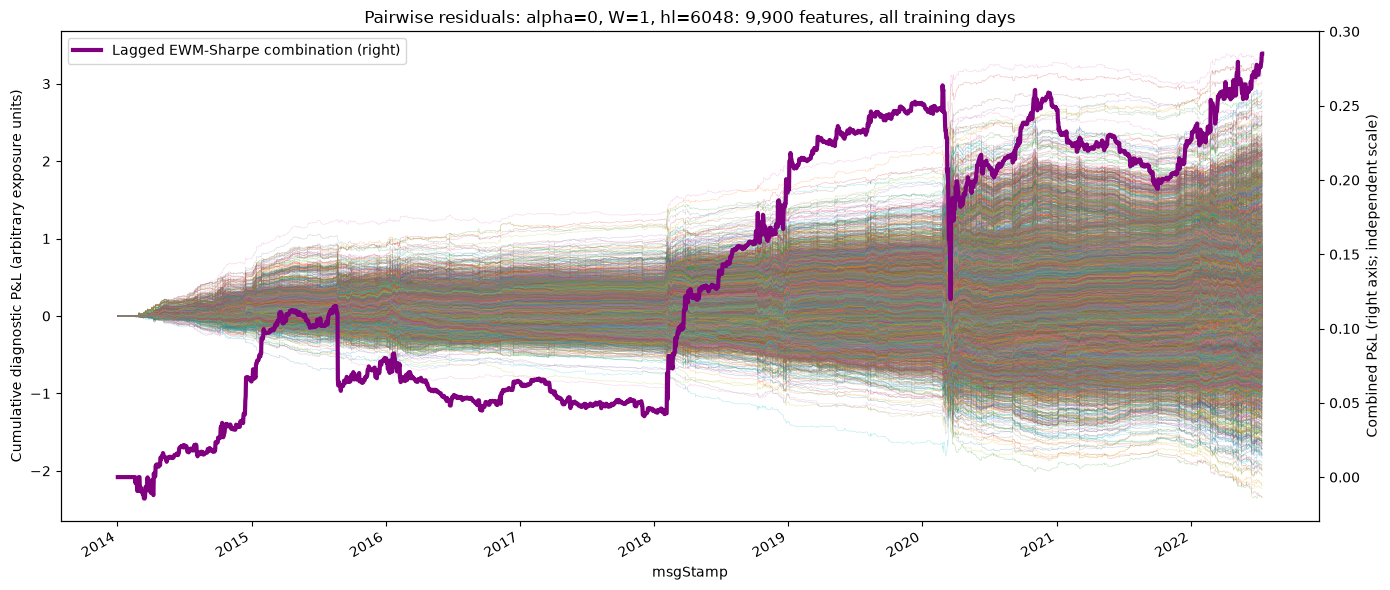

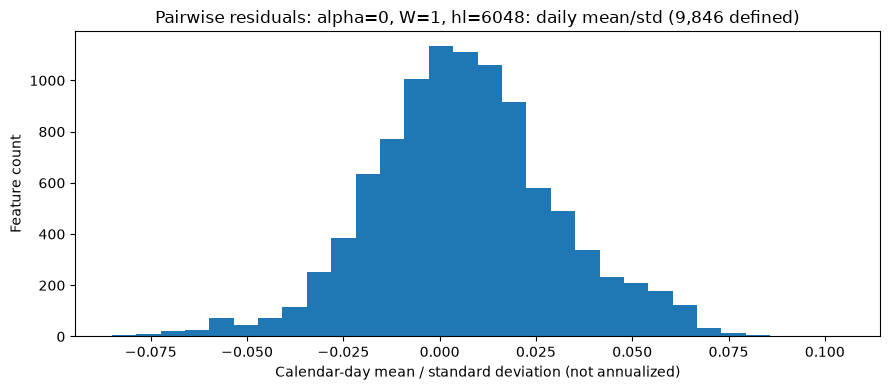

Top 10 of both directed residuals; near-collinear pairs require numerical caution.


,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x2~x58,0.104822,327769,2130,2014-02-26 12:15:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.013788
x1~x58,0.099084,327769,2130,2014-02-26 12:15:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.013053
x58~x2,0.097277,327769,2130,2014-02-26 12:15:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.016869
x58~x1,0.091372,327769,2130,2014-02-26 12:15:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.016466
x2~x34,0.087373,153014,2030,2014-05-07 15:35:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.014829
x44~x58,0.086180,162835,2121,2014-04-23 15:45:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.015139
x58~x41,0.084395,283801,2013,2014-03-20 05:20:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.017016
x19~x61,0.082134,157795,2066,2014-04-25 15:50:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.013194
x44~x61,0.080953,162835,2121,2014-04-23 15:45:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.015127
x58~x40,0.080773,283801,2013,2014-03-20 05:20:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.016096


In [19]:
started = perf_counter()
residual_daily, residual_summary, residual_meta = evaluate_features(
    pairwise_features(raw_features, kind='residual', hl=HL, batch_size=8),
    df['ret_5m'], hl=HL, meta=True, meta_hl=META_HL,
)
experiment_seconds['Pair residuals'] = perf_counter() - started
assert residual_daily.shape[1] == len(x_cols) * (len(x_cols) - 1)
display_results(residual_daily, 'Pairwise residuals: alpha=0, W=1, hl=6048',
                meta_daily=residual_meta.resample('D').sum())
print('Top 10 of both directed residuals; near-collinear pairs require numerical caution.')
display(residual_summary.head(10))
assert residual_summary.max_abs_weight.max() <= SIGNAL_RULE['cap']


### Training-only transformation comparison

Raw and dszl families have 100 candidates; products and directed residuals have 4,950 and 9,900. More trials create more opportunities for a good-looking research result. Compare the distributions and coverage, not only the maximum daily mean/std. All exposures are dimensionless and capped under the same rule, although nonlinear transformations still have different turnover and risk. This is not a claim of incremental or out-of-sample improvement.


In [20]:
experiment_summaries = {
    'Raw baseline': standalone, 'dszl(10)': dszl_summary,
    'Raw products': interaction_summary, 'Pair residuals': residual_summary,
}
comparison_rows = {}
for name, table in experiment_summaries.items():
    s = table['daily_mean_over_std'].dropna()
    comparison_rows[name] = {
        'candidates': len(table), 'defined_sharpes': len(s),
        'median_daily_sharpe': s.median(), 'p95_daily_sharpe': s.quantile(.95),
        'max_daily_sharpe': s.max(), 'min_daily_sharpe': s.min(),
        'positive_fraction': s.gt(0).mean(), 'compute_seconds': experiment_seconds.get(name, np.nan),
    }
transformation_comparison = pd.DataFrame.from_dict(comparison_rows, orient='index')
display(transformation_comparison)
print(transformation_comparison.to_string())
print('Train-only rows:', len(df), '; final training timestamp:', df.index.max())
for name, table in experiment_summaries.items():
    print('\n', name, 'top 5 (training diagnostics)')
    print(table.head(5).to_string())
assert len(df) == split['train_rows'] and df.index.max() < split['cutoff']
assert all(table.max_abs_weight.max() <= SIGNAL_RULE['cap'] for table in experiment_summaries.values())


,candidates,defined_sharpes,median_daily_sharpe,p95_daily_sharpe,max_daily_sharpe,min_daily_sharpe,positive_fraction,compute_seconds
Raw baseline,100,100,0.010576,0.057142,0.065944,-0.121648,0.700000,NaN
dszl(10),100,100,0.012430,0.058730,0.071931,-0.095206,0.740000,13.877793
Raw products,4950,4923,0.006091,0.038810,0.062537,-0.063409,0.604916,321.495907
Pair residuals,9900,9846,0.005680,0.050639,0.104822,-0.085119,0.602783,818.176409


                candidates  defined_sharpes  median_daily_sharpe  p95_daily_sharpe  max_daily_sharpe  min_daily_sharpe  positive_fraction  compute_seconds
Raw baseline           100              100             0.010576          0.057142          0.065944         -0.121648           0.700000              NaN
dszl(10)               100              100             0.012430          0.058730          0.071931         -0.095206           0.740000        13.877793
Raw products          4950             4923             0.006091          0.038810          0.062537         -0.063409           0.604916       321.495907
Pair residuals        9900             9846             0.005680          0.050639          0.104822         -0.085119           0.602783       818.176409
Train-only rows: 640734 ; final training timestamp: 2022-07-14 00:30:00-04:00

 Raw baseline top 5 (training diagnostics)
     daily_mean_over_std  pnl_observations  days_with_observations        first_pnl_msgStamp         la

### Ad hoc lagged EWM-Sharpe combination summary

Estimate each component's score from its **intrabar diagnostic P&L**, not daily P&L:

$$s_{j,t}=\frac{\mathrm{EWMmean}(p_j)_t}{\mathrm{EWMstd}(p_j)_t},\quad
m_{j,t}=\frac{s_{j,t}}{\sum_k |s_{k,t}|},\quad
p_t^{\rm meta}=\sum_j m_{j,t-1}p_{j,t}.$$

Use `halflife=252*288 = 72576` rows and pandas default EWM warm-up. Clip negative scores only for the **raw baseline**; keep signed scores for dszl, products and residuals. Scores with zero/undefined volatility get zero allocation. A zero gross denominator means no position. This fixes the sketch's invalid `hl=` EWM keyword and makes row-wise normalization and the final sum across signals explicit.

```python
moments = ewm_observed(pnls, 252*288)
score = moments.mean().div(moments.std().replace(0, np.nan)).fillna(0)
# Raw signals only: score = score.clip(lower=0)
meta_w = score.div(score.abs().sum(axis=1).replace(0, np.nan), axis=0)
combined = meta_w.shift().mul(pnls).sum(axis=1)
combined.resample('D').sum().cumsum().plot()
```

Pair computations normalize across **all candidates**, not separately inside each eight-column batch. The additive lagged numerator/gross calculation is algebraically identical to the dense formula and is tested against it. Missing current P&L contributes zero without redistributing its previously chosen allocation. Missing values do not count as artificial zero observations when estimating EWM moments.

These are training-only, ad hoc combinations. There is no alpha-sign selection using the full sample, no cost model, no covariance adjustment, and no holdout access. One-row lag is adequate only if the component's preceding P&L is actually observable then; `ret_5m` label availability remains a separate contract. An in-sample adaptive baseline is not a validated out-of-sample Sharpe. The half-life is in rows, not exactly a calendar year.

The actual combined P&L is highlighted in purple in each corresponding family panel above. This section retains the numerical cross-family comparison; member exposures now share the same dimensionless cap; their realized risk and turnover still differ.

In [21]:
meta_pnls = pd.concat({
    'Raw (positive scores)': raw_meta, 'dszl(10) (signed)': dszl_meta,
    'Products (signed)': interaction_meta, 'Residuals (signed)': residual_meta,
}, axis=1)
assert meta_pnls.index.equals(df.index) and np.isfinite(meta_pnls.to_numpy()).all()
meta_daily = meta_pnls.resample('D').sum()
meta_summary = pd.DataFrame({
    'daily_mean_over_std': sharpe(meta_daily), 'daily_mean': meta_daily.mean(),
    'daily_std': meta_daily.std(), 'nonzero_bars': meta_pnls.ne(0).sum(),
    'cumulative_pnl': meta_daily.sum(),
})
display(meta_summary)
print('META_COMBINATIONS'); print(meta_summary.to_string())

,daily_mean_over_std,daily_mean,daily_std,nonzero_bars,cumulative_pnl
Raw (positive scores),0.039707,0.000210,0.005286,448455,0.653984
dszl(10) (signed),0.044814,0.000153,0.003411,489171,0.476286
Products (signed),-0.003717,-0.000006,0.001682,448365,-0.019482
Residuals (signed),0.036308,0.000091,0.002520,448363,0.285101


META_COMBINATIONS
                       daily_mean_over_std  daily_mean  daily_std  nonzero_bars  cumulative_pnl
Raw (positive scores)             0.039707    0.000210   0.005286        448455        0.653984
dszl(10) (signed)                 0.044814    0.000153   0.003411        489171        0.476286
Products (signed)                -0.003717   -0.000006   0.001682        448365       -0.019482
Residuals (signed)                0.036308    0.000091   0.002520        448363        0.285101


### Optimistic future-predictor diagnostic — h=1 only

Use `df[x_cols].shift(-1)` as the only look-ahead experiment. Keep **h=0 as a causal-input control**, not as another oracle horizon. This asks whether knowing the next predictor value could help; it is deliberately noncausal and is not an achievable backtest or a guarantee of a forecastable upper bound.

Shifts are applied only after the training split. Both control and oracle exclude the **last one target row** for a common endpoint, rather than discarding 24 rows. Leads count dataframe rows, not elapsed minutes across gaps. Feature missingness is reported separately. Both use the existing `evaluate_features` sizing and lagged EWM-Sharpe combination; no reserved-window targets enter the experiment.


#### Predictor lead h=0 — causal-input control

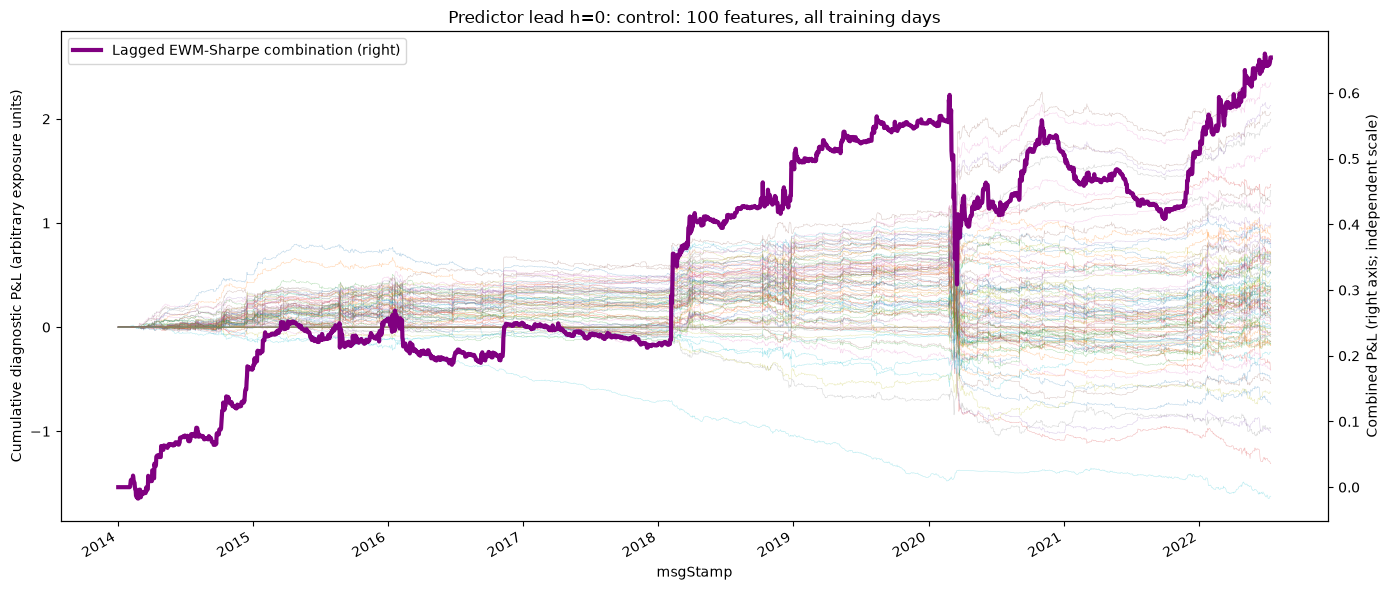

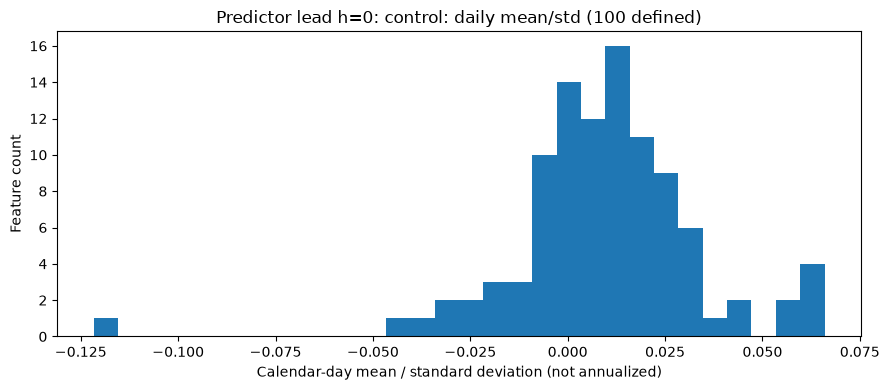

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x76,0.065944,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.019055
x85,0.062096,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.018704
x86,0.062035,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.017966
x77,0.061200,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.018757
x87,0.059069,228875,2145,2014-03-24 07:05:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.015948
x78,0.057041,332666,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.016951
x94,0.046554,153522,2064,2014-04-29 12:20:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.017548
x97,0.042411,147765,2058,2014-05-07 12:00:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.018387
x58,0.037774,332731,2163,2014-02-26 12:05:00-05:00,2022-07-13 16:00:00-04:00,3.0,0.019297
x95,0.034551,153522,2064,2014-04-29 12:20:00-04:00,2022-07-13 16:00:00-04:00,3.0,0.018284


In [22]:
h = 0
oracle_returns = df.ret_5m.where(rows < len(df)-1)
blocks = (df[x_cols[start:start+8]].shift(-h) for start in range(0,len(x_cols),8))
oracle_daily, oracle_summary, oracle_meta = evaluate_features(
    blocks, oracle_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
display_results(oracle_daily, f'Predictor lead h={h}: '+('control' if h==0 else 'LOOK-AHEAD'),
                meta_daily=oracle_meta.resample('D').sum())
if h==0:
    oracle_records, oracle_score_columns = [], {}
scores=oracle_summary.daily_mean_over_std
oracle_score_columns[h]=scores
oracle_records.append(dict(h=h, candidates=len(scores), defined=int(scores.notna().sum()),
    median_sharpe=scores.median(), p95_sharpe=scores.quantile(.95), best_sharpe=scores.max(),
    meta_sharpe=sharpe(oracle_meta.resample('D').sum()),
    median_pnl_observations=oracle_summary.pnl_observations.median()))
display(oracle_summary.head(10))


#### Predictor lead h=1 — LOOK-AHEAD

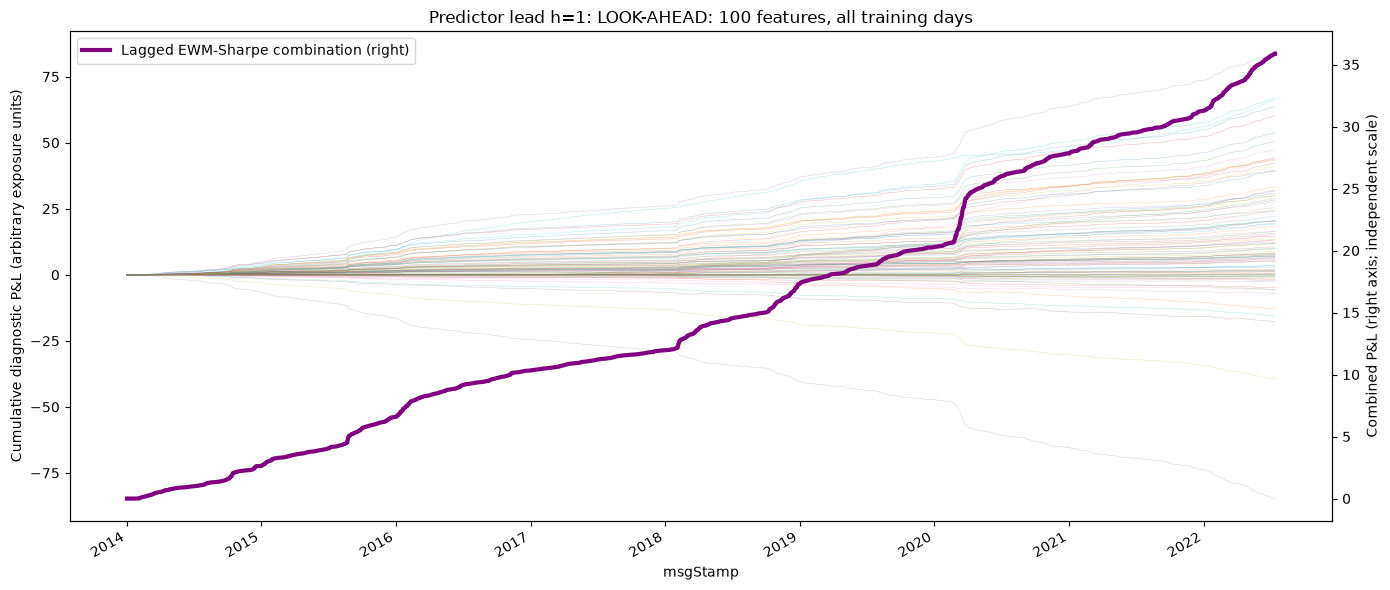

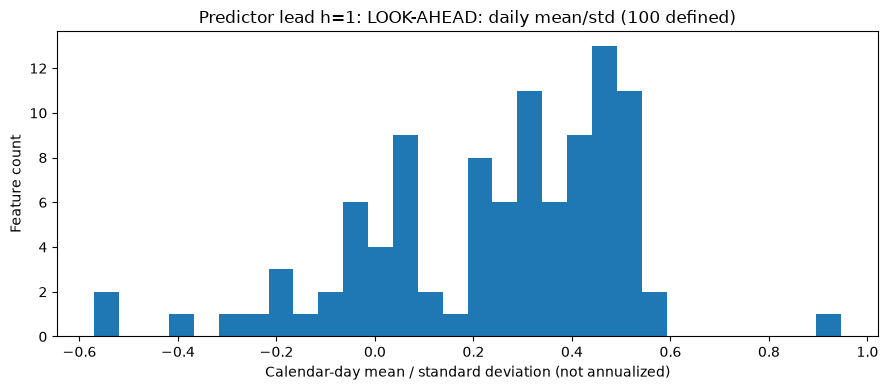

,daily_mean_over_std,pnl_observations,days_with_observations,first_pnl_msgStamp,last_pnl_msgStamp,max_abs_weight,capped_fraction
x100,0.945583,578331,2621,2014-02-03 10:50:00-05:00,2022-07-14 00:25:00-04:00,3.0,0.008758
x55,0.582514,472780,2580,2014-03-06 14:15:00-05:00,2022-07-14 00:25:00-04:00,3.0,0.018631
x7,0.547084,338801,1693,2017-02-05 22:00:00-05:00,2022-07-14 00:25:00-04:00,3.0,0.024088
x56,0.534155,472780,2580,2014-03-06 14:15:00-05:00,2022-07-14 00:25:00-04:00,3.0,0.018519
x1,0.530558,327821,2130,2014-02-26 12:05:00-05:00,2022-07-13 15:55:00-04:00,3.0,0.015655
x4,0.529848,323779,2111,2014-02-26 12:05:00-05:00,2022-07-13 15:55:00-04:00,3.0,0.014738
x49,0.519420,166707,2116,2014-04-22 10:45:00-04:00,2022-07-13 16:10:00-04:00,3.0,0.017023
x52,0.517758,161363,2114,2014-04-24 10:15:00-04:00,2022-07-13 15:50:00-04:00,3.0,0.017265
x37,0.505510,162775,2121,2014-04-23 15:40:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.016114
x13,0.504086,146338,1372,2017-03-22 13:00:00-04:00,2022-07-13 15:55:00-04:00,3.0,0.016420


In [23]:
h = 1
oracle_returns = df.ret_5m.where(rows < len(df)-1)
blocks = (df[x_cols[start:start+8]].shift(-h) for start in range(0,len(x_cols),8))
oracle_daily, oracle_summary, oracle_meta = evaluate_features(
    blocks, oracle_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=True)
display_results(oracle_daily, f'Predictor lead h={h}: '+('control' if h==0 else 'LOOK-AHEAD'),
                meta_daily=oracle_meta.resample('D').sum())
if h==0:
    oracle_records, oracle_score_columns = [], {}
scores=oracle_summary.daily_mean_over_std
oracle_score_columns[h]=scores
oracle_records.append(dict(h=h, candidates=len(scores), defined=int(scores.notna().sum()),
    median_sharpe=scores.median(), p95_sharpe=scores.quantile(.95), best_sharpe=scores.max(),
    meta_sharpe=sharpe(oracle_meta.resample('D').sum()),
    median_pnl_observations=oracle_summary.pnl_observations.median()))
display(oracle_summary.head(10))


In [24]:
oracle_comparison=pd.DataFrame(oracle_records).set_index('h')
per_feature_oracle=pd.DataFrame(oracle_score_columns)
for h in [1]:
    delta=per_feature_oracle[h]-per_feature_oracle[0]
    oracle_comparison.loc[h,'median_sharpe_change_vs_h0']=delta.median()
    oracle_comparison.loc[h,'fraction_improved_vs_h0']=delta.gt(0).where(delta.notna()).mean()
display(oracle_comparison)
print('ORACLE_SHIFT_SUMMARY'); print(oracle_comparison.to_string())
assert df.index.max()<split['cutoff']


,candidates,defined,median_sharpe,p95_sharpe,best_sharpe,meta_sharpe,median_pnl_observations,median_sharpe_change_vs_h0,fraction_improved_vs_h0
h,,,,,,,,,
0,100,100,0.010576,0.057142,0.065944,0.039707,160014.0,NaN,NaN
1,100,100,0.304534,0.529883,0.945583,0.570885,160013.0,0.288235,0.81


ORACLE_SHIFT_SUMMARY
   candidates  defined  median_sharpe  p95_sharpe  best_sharpe  meta_sharpe  median_pnl_observations  median_sharpe_change_vs_h0  fraction_improved_vs_h0
h                                                                                                                                                        
0         100      100       0.010576    0.057142     0.065944     0.039707                 160014.0                         NaN                      NaN
1         100      100       0.304534    0.529883     0.945583     0.570885                 160013.0                    0.288235                     0.81


### Forecast each alpha one period ahead with Streaming Lasso

Each raw feature x1 through x100 has continuous, causal AR(2) candidate models: once x_t is observed, they learn through x_t and forecast x_(t+1) using x_t and x_(t-1). The original 6,048-row EWM fitting and warm-up conventions are retained. Initial nonzero-feature scale is frozen after the warm-up; no return target enters these fits.

The regularization parameter is no longer a fixed illustration. For each feature separately, **the candidate with the smallest next-feature MSE on the preceding two-year test block supplies forecasts for the next block**. The last decision in a validation block is excluded because its x_(t+1) target may not yet be known. The first test block is initial tuning only. Candidate states remain continuous online EWMs; these are feature-forecast experiments, not the final frozen return model. Missing current/lag observations and incomplete initial warm-up are excluded identically for all candidates, without conditioning causal P&L on a future feature value.


#### Prior-test selection for AR(2) regularization

The grid is evaluated using next-feature squared forecast error, not trading returns. Each feature gets its own choice, held constant over the next two-year block. The table records validation boundaries and the next application block, and the plotted counts show how the chosen penalty changes. No candidate is chosen from the block in which the selected forecast is evaluated.


Sparse or late-starting features may have no mature examples in an earlier validation block. Their next block remains **unavailable**, not filled with a fixed-alpha forecast or a winner chosen from future data. Selection resumes only after a completed preceding block supplies eligible examples. Pending choices and coverage are displayed; persistence/oracle controls use the same causal availability mask. All 200 return-model input columns are still retained.


/home/runner/work/th/th/src/takehome/fitters.py:747: RuntimeWarning: 1 updates did not converge; inspect KKT errors or raise max_iter.
  model.fit(lags/scale, values/scale, W=valid.astype(float))


/home/runner/work/th/th/src/takehome/fitters.py:747: RuntimeWarning: 1 updates did not converge; inspect KKT errors or raise max_iter.
  model.fit(lags/scale, values/scale, W=valid.astype(float))


,fold,validation_fold,candidate,validation_start,validation_stop,validation_rows,validation_mse,predict_start,predict_stop,status,feature
0,1,0,0.001,150191,300383,77768,2.593725e-07,300384,450720,selected,x1
1,2,1,0.001,300384,450719,76845,2.168576e-07,450720,600911,selected,x1
2,3,2,0.001,450720,600910,77625,5.990000e-07,600911,640734,selected,x1
3,1,0,0.001,150191,300383,77768,1.192187e-07,300384,450720,selected,x2
4,2,1,0.001,300384,450719,76845,9.953068e-08,450720,600911,selected,x2
...,...,...,...,...,...,...,...,...,...,...,...
295,2,1,0.001,300384,450719,32743,2.889444e-09,450720,600911,selected,x99
296,3,2,0.001,450720,600910,35317,1.265177e-08,600911,640734,selected,x99
297,1,0,0.001,150191,300383,134339,8.340484e-02,300384,450720,selected,x100
298,2,1,0.001,300384,450719,135166,3.848288e-02,450720,600911,selected,x100


,n,rmse_vs_persistence
count,100.000000,97.000000
mean,117564.050000,0.851522
std,67809.676193,0.094889
min,0.000000,0.696357
25%,77937.000000,0.732606
50%,87456.000000,0.869089
75%,135210.250000,0.953622
max,310835.000000,0.996993


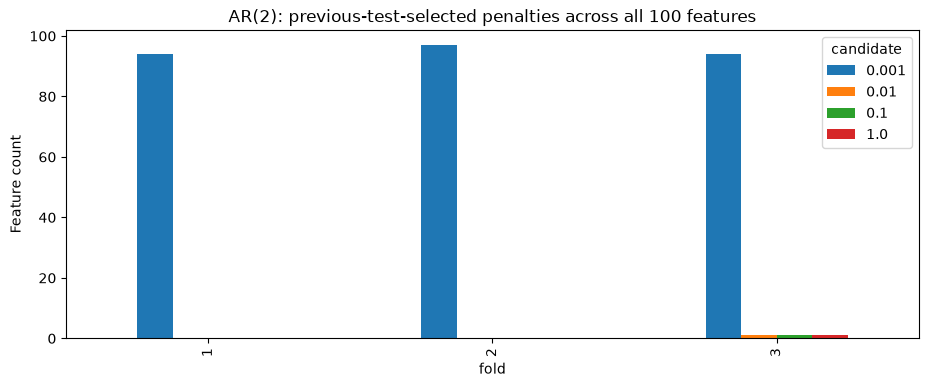

AR_SELECTED 100 features; 300 lagged choices; 400.4824460159998 seconds
Candidate nonconverged updates: 2
AR fold choices waiting for completed historical validation: 12


,feature,fold,validation_rows,status
27,x10,1,0,waiting_for_validation
30,x11,1,0,waiting_for_validation
33,x12,1,0,waiting_for_validation
198,x67,1,0,waiting_for_validation
199,x67,2,0,waiting_for_validation
200,x67,3,0,waiting_for_validation
201,x68,1,0,waiting_for_validation
202,x68,2,0,waiting_for_validation
203,x68,3,0,waiting_for_validation
204,x69,1,0,waiting_for_validation


In [4]:
from takehome.selection import forecast_alpha_selected
from takehome.fitters import calendar_walk_forward_folds

AR_ALPHAS, AR_MIN_TRAIN = [1., .1, .01, .001], HL
alpha_folds = calendar_walk_forward_folds(df.index, train_years=WINDOW_YEARS, test_years=WINDOW_YEARS)
alpha_first = alpha_folds[1]['predict_start']
alpha_returns = df.ret_5m.where(rows < len(df)-1)
ar_decisions, ar_fit_records, ar_error_rows = [], [], []
ar_fold_choices = {}

def selected_alpha_blocks():
    for start in range(0, len(x_cols), BATCH_SIZE):
        predictions = {}
        for col in x_cols[start:start+BATCH_SIZE]:
            prediction, info = forecast_alpha_selected(df[col], folds=alpha_folds,
                alphas=AR_ALPHAS, hl=HL, min_train=AR_MIN_TRAIN)
            predictions[col] = prediction
            ar_fold_choices[col] = info['choices']
            ar_decisions.append(info['selection'].assign(feature=col))
            ar_fit_records.extend(info['candidates'])
            actual = df[col].shift(-1)  # Evaluation only; never an input to selection before maturity.
            valid = prediction.notna() & actual.notna() & df[col].notna()
            error = (prediction[valid]-actual[valid]).pow(2).mean()
            persistence_error = (df.loc[valid,col]-actual[valid]).pow(2).mean()
            ar_error_rows.append(dict(feature=col, n=int(valid.sum()),
                rmse_vs_persistence=np.sqrt(error/persistence_error) if persistence_error>0 else np.nan))
        yield pd.DataFrame(predictions, index=df.index)

started = perf_counter()
ar_selected_daily, ar_selected_summary, ar_selected_meta = evaluate_features(
    selected_alpha_blocks(), alpha_returns, hl=HL, meta=True, meta_hl=META_HL, positive_only=False)
ar_selection_table = pd.concat(ar_decisions, ignore_index=True)
ar_candidate_audit = pd.DataFrame(ar_fit_records)
ar_error_table = pd.DataFrame(ar_error_rows).set_index('feature')
display(ar_selection_table, ar_error_table.describe())
counts = ar_selection_table.groupby(['fold','candidate']).size().unstack('candidate', fill_value=0)
counts.plot(kind='bar', figsize=(11,4), title='AR(2): previous-test-selected penalties across all 100 features')
plt.ylabel('Feature count'); plt.show(); plt.close('all')
print('AR_SELECTED', len(ar_error_table), 'features;', len(ar_selection_table), 'lagged choices;',
      perf_counter()-started, 'seconds')
print('Candidate nonconverged updates:', int(ar_candidate_audit.failed_updates.sum()))
assert (ar_selection_table.validation_stop <= ar_selection_table.predict_start).all()

waiting = ar_selection_table.status.eq('waiting_for_validation')
print('AR fold choices waiting for completed historical validation:', int(waiting.sum()))
display(ar_selection_table.loc[waiting, ['feature','fold','validation_rows','status']])


#### Backtest the prior-test-selected AR(2) forecasts

Only the stitched next-block forecast is evaluated. The initial tuning block is not a selected strategy result. The combination uses earlier P&Ls with the same signed weighting rule as its controls. No regularization value is selected from these plotted returns.


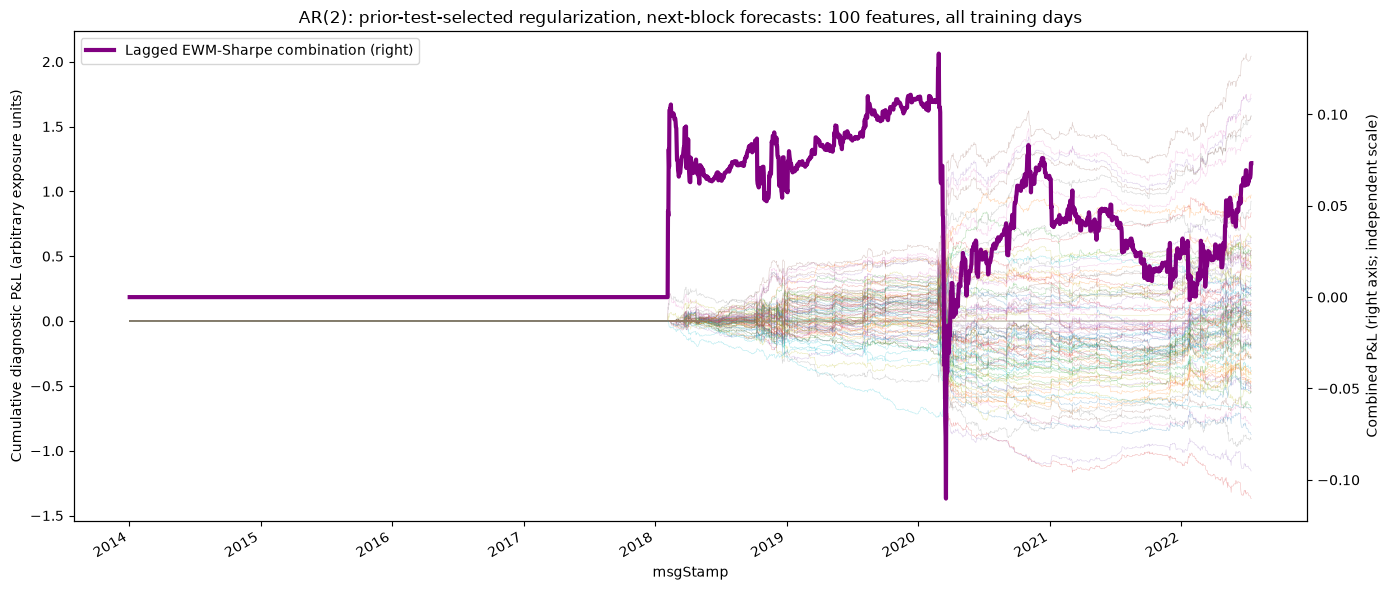

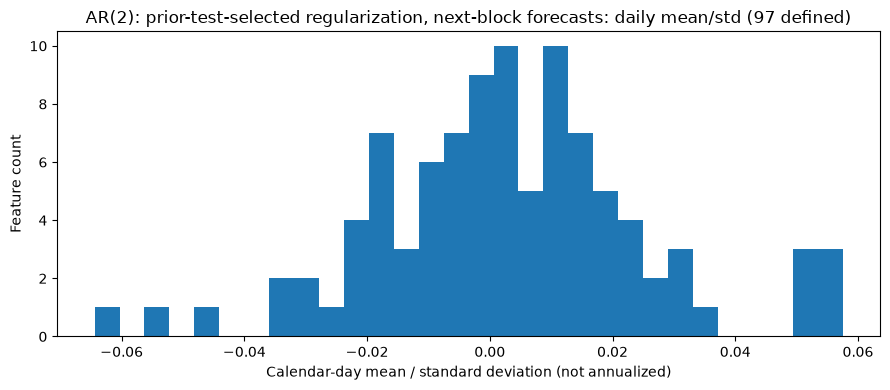

x1      0.000666
x2      0.014994
x3      0.019760
x4     -0.016985
x5     -0.006905
          ...   
x96     0.022384
x97     0.022726
x98     0.013218
x99     0.014984
x100   -0.064410
Length: 100, dtype: float64

In [5]:
display_results(ar_selected_daily, 'AR(2): prior-test-selected regularization, next-block forecasts',
                meta_daily=ar_selected_meta.resample('D').sum())


#### Matched persistence and realized-future controls

The persistence input is the current alpha, which is the forecast x_{t+1}=x_t. It uses exactly the same **causal** warm-up and current-lag availability rule as AR(2). The oracle uses the actual next value; it may additionally be missing when that future value is unavailable. No future-availability condition is imposed on the AR(2) or persistence backtests. The final training target row is omitted from all three. Volatility warm-ups can still differ when a forecast is exactly zero, so coverage is reported by the underlying summaries.


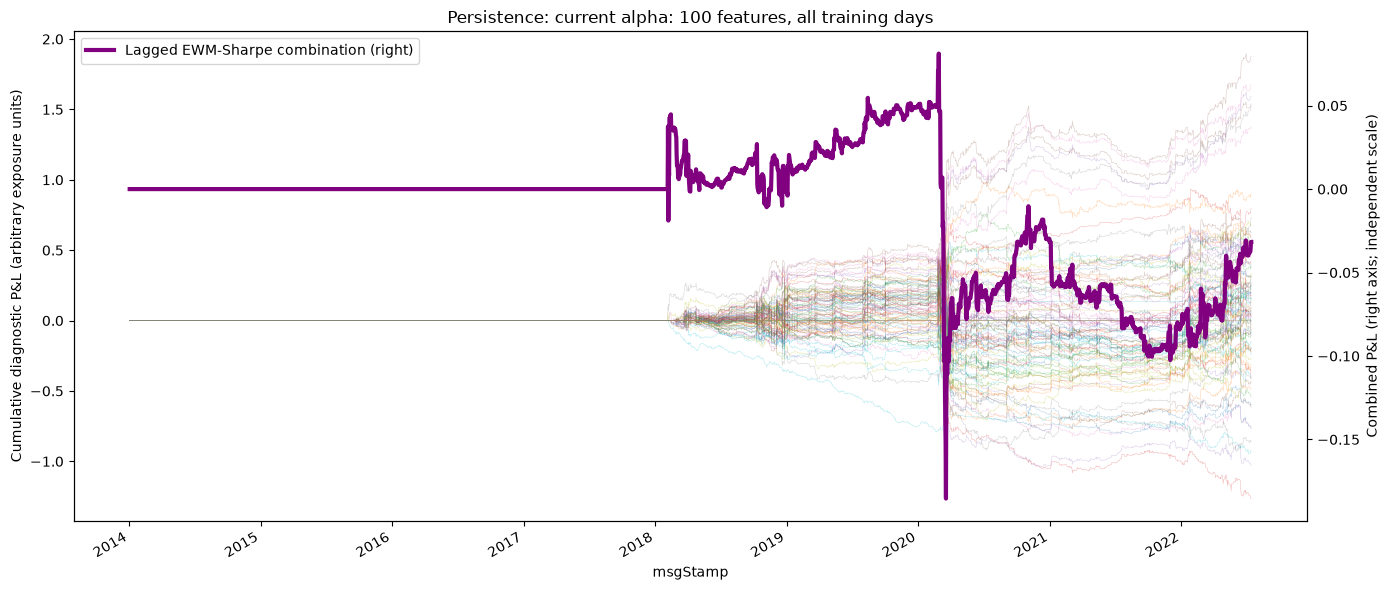

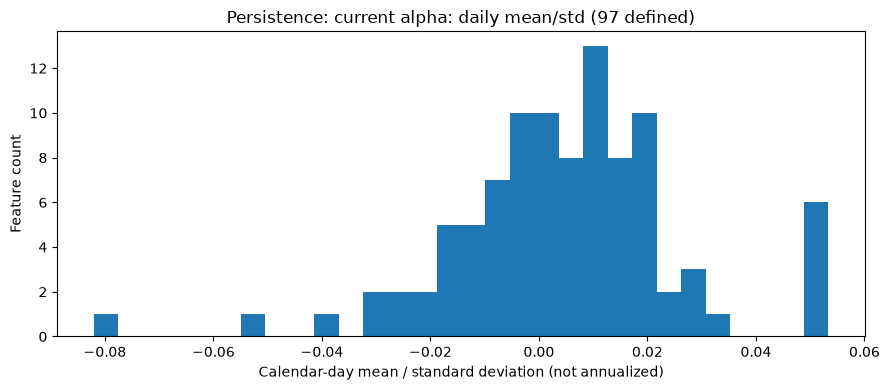

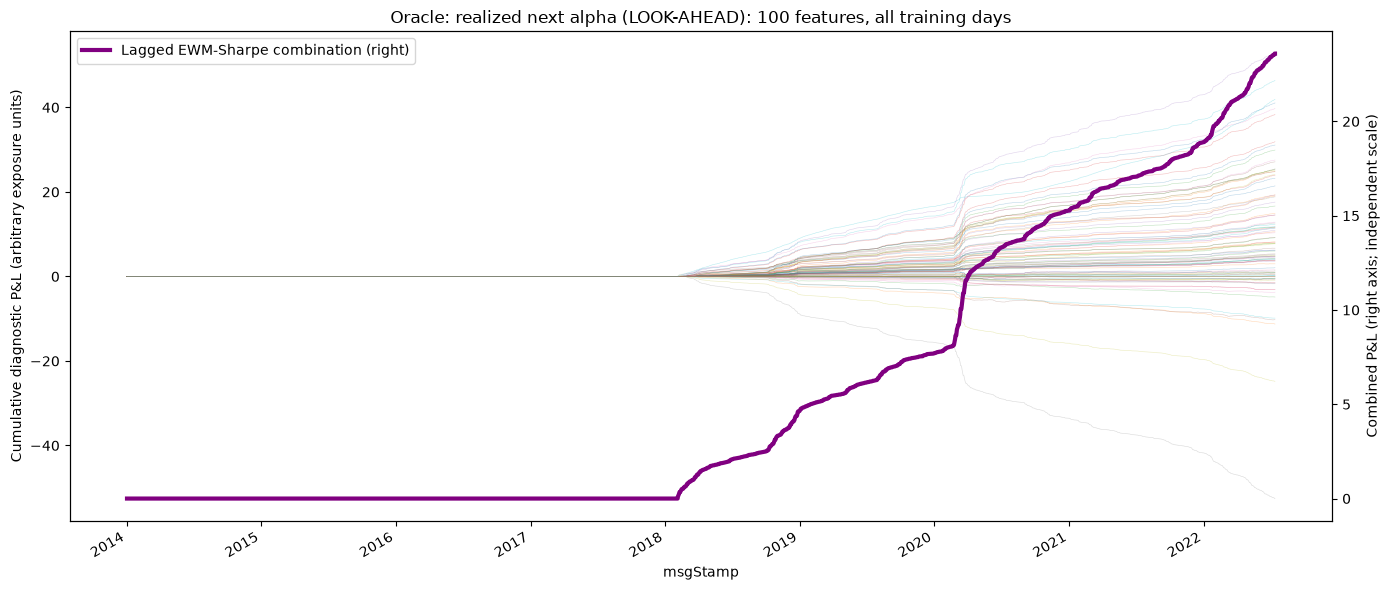

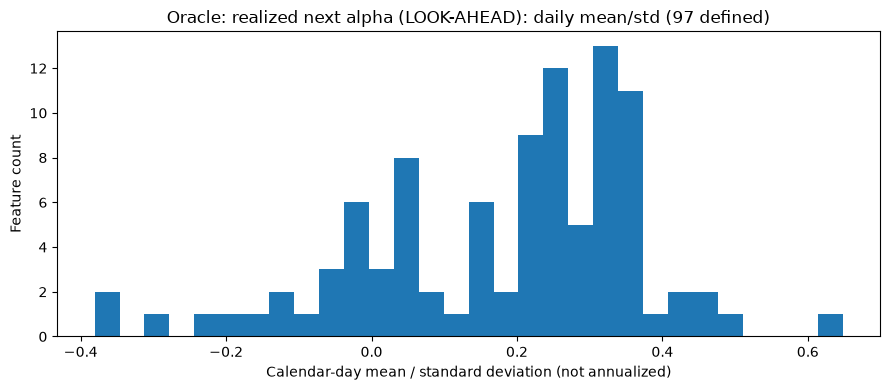

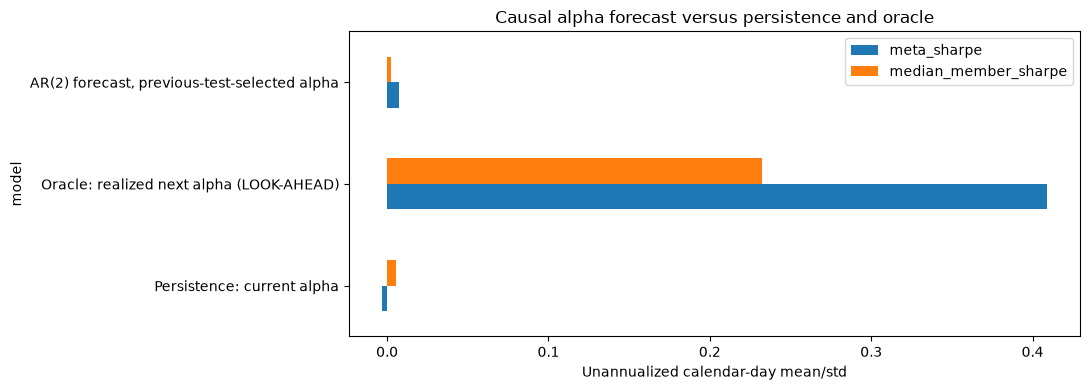

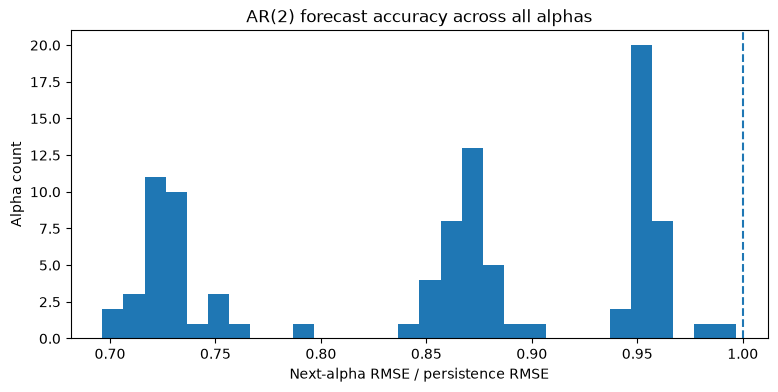

Prior-test-selected AR(2): 97/97 alphas beat persistence on forecast RMSE; median ratio=0.8691.
Persistence: current alpha: meta daily Sharpe=-0.003036; median member Sharpe=0.005519; median PnL observations=82549
Oracle: realized next alpha (LOOK-AHEAD): meta daily Sharpe=0.408802; median member Sharpe=0.232461; median PnL observations=81408
AR(2) forecast, previous-test-selected alpha: meta daily Sharpe=0.007441; median member Sharpe=0.002538; median PnL observations=82549


In [6]:
def matched_alpha_controls(oracle=False):
    for start in range(0,len(x_cols),8):
        X=df[x_cols[start:start+8]].replace([np.inf,-np.inf],np.nan)
        triples=X.notna() & X.shift(1).notna() & X.shift(2).notna()
        ready=triples.cumsum().ge(AR_MIN_TRAIN) & X.notna() & X.shift(1).notna()
        ready=ready.where(pd.Series(rows >= alpha_first, index=df.index), False, axis=0)
        for j,col in enumerate(X.columns):
            for fold,choice in zip(alpha_folds, ar_fold_choices[col]):
                if choice is None:
                    ready.iloc[fold['predict_start']:fold['predict_stop'], j] = False
        yield (X.shift(-1) if oracle else X).where(ready)

control_records=[]
for oracle,label in [(False,'Persistence: current alpha'),(True,'Oracle: realized next alpha (LOOK-AHEAD)')]:
    days,summary,meta=evaluate_features(matched_alpha_controls(oracle),alpha_returns,
                                      hl=HL,meta=True,meta_hl=META_HL,positive_only=False)
    display_results(days,label,meta_daily=meta.resample('D').sum())
    control_records.append(dict(model=label,meta_sharpe=sharpe(meta.resample('D').sum()),
        median_member_sharpe=summary.daily_mean_over_std.median(),
        median_pnl_observations=summary.pnl_observations.median()))
control_records.append(dict(model='AR(2) forecast, previous-test-selected alpha',meta_sharpe=sharpe(ar_selected_meta.resample('D').sum()),
    median_member_sharpe=ar_selected_summary.daily_mean_over_std.median(),
    median_pnl_observations=ar_selected_summary.pnl_observations.median()))
ar_comparison=pd.DataFrame(control_records).set_index('model')
ar_comparison[['meta_sharpe','median_member_sharpe']].plot.barh(figsize=(11,4),title='Causal alpha forecast versus persistence and oracle')
plt.xlabel('Unannualized calendar-day mean/std'); plt.tight_layout(); plt.show(); plt.close('all')
ratios=ar_error_table.rmse_vs_persistence.dropna()
plt.figure(figsize=(9,4)); plt.hist(ratios,bins=30)
plt.axvline(1,linestyle='--'); plt.xlabel('Next-alpha RMSE / persistence RMSE')
plt.ylabel('Alpha count'); plt.title('AR(2) forecast accuracy across all alphas'); plt.show(); plt.close('all')
print(f'Prior-test-selected AR(2): {ratios.lt(1).sum()}/{len(ratios)} alphas beat persistence on forecast RMSE; median ratio={ratios.median():.4f}.')
assert df.index.max()<split['cutoff']

for name, row in ar_comparison.iterrows():
    print(f'{name}: meta daily Sharpe={row.meta_sharpe:.6f}; median member Sharpe={row.median_member_sharpe:.6f}; median PnL observations={row.median_pnl_observations:g}')


## Walk-forward regression with genuinely next-fold hyperparameter selection

Concatenate the **100 raw and 100 dszl(10) predictors** in that order. Each candidate learns centering and feature-penalty scales only inside its preceding two-year training interval. The time-of-day feature state is causal and continues across boundaries. Nonfinite model inputs are zero-imputed after construction; labels are never filled.

For candidate alpha and fold k: train on the preceding two years, hold the candidate fixed over test block k, and compute raw-return MSE there. The winner of block k is **used only in block k+1**, after refitting on that next fold's training data. The first test block is used for tuning, not for a static-alpha backtest. A one-row embargo excludes the last validation label and one row at training cutoffs. The final research block may be partial; a separate full two-year validation block selects the eventual holdout alpha.

Grids are fixed before this evaluation. Both Ridge and Lasso have independent previous-test choices. The plot reports the resulting adaptive strategies, not the best full-period constant penalty. Previous test data may become subsequent training data; that is permitted after it has been observed.

<span style="color:red">TODO — fitting: assess weighting by volume, because feasible size to be traded is proxied by market volume. Keep this separate from signal sizing and distinguish observed volume from information available at the trading decision. Current model and selection weights are unit on finite labels; volume weighting is not silently implemented.</span>


In [7]:
from takehome.fitters import (StreamingWeightedLasso, BatchRidge, BatchLasso,
    CvxpyWeightedLasso, BatchedFitters, walk_forward_sweep, calendar_walk_forward_folds,
    batch_moments, _scaled_moments)
from takehome.selection import select_walk_forward_paths, walk_forward_select, stream_selected_folds
from takehome.features import backtest, forecast_metrics
from takehome.plots import plot_calibration
from time import perf_counter

base_columns = list(x_cols)
assert len(base_columns) == 100 and base_columns[-1] == 'x100'
model_X = raw_dszl_design(df[base_columns], hl=DSZL_HL, batch_size=BATCH_SIZE)
fit_columns = model_X.columns.tolist()
assert fit_columns == [f'raw:{c}' for c in base_columns] + [f'dszl:{c}' for c in base_columns]
X_fit = model_X.to_numpy(copy=False)
assert X_fit.flags.c_contiguous and np.isfinite(X_fit).all() and X_fit.shape[1] == 200
y_fit = df.ret_5m.to_numpy(dtype=float)
valid_fit = np.isfinite(y_fit)
W_fit = valid_fit.astype(float)
DECAY = RIDGE_CONFIG['decay']
folds = calendar_walk_forward_folds(df.index, train_years=WINDOW_YEARS,
                                   test_years=WINDOW_YEARS, gap=SELECTION_EMBARGO)
assert len(folds) >= 2
FOLD = dict(folds=folds)
OOS_FIRST = folds[1]['predict_start']  # Fold zero is tuning only, not static-alpha evaluation.
SCORE_FIRST = OOS_FIRST + HL
rows = np.arange(len(df))
score_day = df.index[SCORE_FIRST].normalize()

def oos_series(values):
    return pd.Series(values, index=df.index).where(rows >= OOS_FIRST)

def score_prediction(prediction):
    per_bar = backtest(prediction, df.ret_5m, HL, normalization=SIGNAL_RULE).where(rows >= SCORE_FIRST)
    daily = per_bar.resample('D').sum().loc[score_day:]
    stats = forecast_metrics(prediction.iloc[SCORE_FIRST:], df.ret_5m.iloc[SCORE_FIRST:])
    return daily, dict(daily_sharpe=sharpe(daily), pnl_observations=int(per_bar.count()),
        max_abs_weight=signal_weights(prediction, HL, **SIGNAL_RULE).abs().max(), **stats)

fold_table = pd.DataFrame(folds)
display(fold_table)
print('DESIGN:', X_fit.shape, '[raw X, dszl(X,10)]')
print('Initial tuning block:', df.index[folds[0]['predict_start']], 'to', df.index[folds[0]['predict_stop']-1])
print('First selected OOS forecast:', df.index[OOS_FIRST], '; scoring after signal warm-up:', df.index[SCORE_FIRST])


,train_start,train_stop,predict_start,predict_stop,train_start_time,train_stop_time,predict_start_time,predict_stop_time
0,0,150190,150191,300384,2014-01-02 06:05:00-05:00,2016-01-02 06:05:00-05:00,2016-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00
1,150191,300383,300384,450720,2016-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00,2018-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00
2,300384,450719,450720,600911,2018-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00,2020-01-02 06:05:00-05:00,2022-01-02 06:05:00-05:00
3,450720,600910,600911,640734,2020-01-02 06:05:00-05:00,2022-01-02 06:05:00-05:00,2022-01-02 06:05:00-05:00,2024-01-02 06:05:00-05:00


DESIGN: (640734, 200) [raw X, dszl(X,10)]
Initial tuning block: 2016-01-03 18:00:00-05:00 to 2018-01-02 06:00:00-05:00
First selected OOS forecast: 2018-01-02 06:05:00-05:00 ; scoring after signal warm-up: 2018-01-31 06:05:00-05:00


## Numerical reference: direct CVXPY residual loss

This synthetic check uses exactly matched prefix observations, decay, feature-scaled penalty and intercept convention. The later real-data checks separately compare two-year-window batch moments and frozen forecasts.

In [29]:
# Independent CVXPY loss at identical prefixes; no Numba Gram/CD reuse.
from takehome.fitters import StreamingWeightedLasso, CvxpyWeightedLasso, BatchedFitters

rng = np.random.default_rng(42)
X_check = rng.normal(size=(256, 4)) * [1, 2, 3, 4] + .3
y_check = .2 + X_check @ np.array([.6, 0, -.3, .15]) + rng.normal(size=256) * .1
v_check = (rng.uniform(1800, 2200, 256) * rng.lognormal(4, 1, 256))**2
decay, alpha = .99, .05
verification = []
for with_intercept in [False, True]:
    online = StreamingWeightedLasso(4, decay, alpha, max_iter=50000, tol=1e-11,
                                    fit_intercept=with_intercept, store_history=True).fit(X_check, y_check, W=v_check)
    for n in [32, 64, 128, 256]:
        ref = CvxpyWeightedLasso(4, decay, alpha, fit_intercept=with_intercept, tol=1e-12)
        ref.fit(X_check[:n], y_check[:n], W=v_check[:n])
        beta, bias = online.get_coefs()[n-1], online.get_intercepts()[n-1]
        a = v_check[:n] * decay**np.arange(n-1, -1, -1); a /= a.sum()
        loss_online = .5 * (a @ (y_check[:n] - X_check[:n] @ beta - bias)**2)
        loss_online += alpha * np.sum(ref.scale_ * np.abs(beta))
        verification.append({
            'intercept': with_intercept, 'prefix_rows': n,
            'max_coefficient_error': np.max(np.abs(beta-ref.coef)),
            'max_prediction_error': np.max(np.abs(X_check[:n] @ beta+bias-ref.predict(X_check[:n]))),
            'objective_gap': abs(loss_online-ref.objective_), 'cvxpy_status': ref.status_,
        })
    assert online.n_failed_ == 0
verification = pd.DataFrame(verification)
with pd.option_context('display.float_format', '{:.3e}'.format):
    display(verification)
print('CVXPY_RECONCILIATION'); print(verification.to_string(index=False))
assert verification.max_coefficient_error.max() < 5e-7
assert verification.max_prediction_error.max() < 2e-6
assert verification.objective_gap.max() < 1e-9

,intercept,prefix_rows,max_coefficient_error,max_prediction_error,objective_gap,cvxpy_status
0,False,32,9.180e-12,1.798e-11,9.798e-15,optimal
1,False,64,2.430e-12,1.106e-11,1.870e-13,optimal
2,False,128,7.286e-11,2.514e-10,1.388e-17,optimal
3,False,256,1.121e-11,6.500e-11,3.873e-14,optimal
4,True,32,3.299e-11,6.444e-11,1.388e-17,optimal
5,True,64,1.580e-11,5.286e-11,4.577e-14,optimal
6,True,128,3.774e-11,1.281e-10,7.340e-14,optimal
7,True,256,1.708e-11,7.006e-11,1.601e-13,optimal


CVXPY_RECONCILIATION
 intercept  prefix_rows  max_coefficient_error  max_prediction_error  objective_gap cvxpy_status
     False           32           9.179768e-12          1.797673e-11   9.797718e-15      optimal
     False           64           2.429501e-12          1.106049e-11   1.870171e-13      optimal
     False          128           7.286183e-11          2.513921e-10   1.387779e-17      optimal
     False          256           1.121292e-11          6.499645e-11   3.873291e-14      optimal
      True           32           3.299450e-11          6.443518e-11   1.387779e-17      optimal
      True           64           1.579625e-11          5.286119e-11   4.576894e-14      optimal
      True          128           3.774026e-11          1.281258e-10   7.339962e-14      optimal
      True          256           1.708045e-11          7.005918e-11   1.600664e-13      optimal


## Batch Ridge and Lasso: prior-test winners applied to the following fold

All candidates at a cutoff reuse independently computed batch moments. The tables below show each test block's candidate MSE and the winner **applied to the next block**. Candidate test scores are tuning data, not the adaptive strategy's reported return. No fold selects its own penalty, and there is no fixed reference alpha in the primary backtest.


### Ridge: selection audit

,fold,validation_fold,selected_alpha,validation_start,validation_stop,validation_rows,validation_mse,predict_start,predict_stop,status,validation_first,validation_last,apply_from
0,1,0,100.0,150191,300383,137725,1.883719e-07,300384,450720,selected,2016-01-03 18:00:00-05:00,2018-01-02 05:55:00-05:00,2018-01-02 06:05:00-05:00
1,2,1,100.0,300384,450719,137889,3.755647e-07,450720,600911,selected,2018-01-02 06:05:00-05:00,2020-01-02 05:55:00-05:00,2020-01-02 06:05:00-05:00
2,3,2,10.0,450720,600910,138845,8.767401e-07,600911,640734,selected,2020-01-02 06:05:00-05:00,2021-12-31 17:50:00-05:00,2022-01-02 18:00:00-05:00


candidate,0.000001,0.000010,0.000100,0.001000,0.010000,0.100000,1.000000,10.000000,100.000000
fold,,,,,,,,,
0,2.035449e-07,2.030279e-07,2.012974e-07,1.980806e-07,1.947696e-07,1.910387e-07,1.889086e-07,1.884193e-07,1.883719e-07
1,3.940572e-07,3.937208e-07,3.929941e-07,3.909391e-07,3.853009e-07,3.788932e-07,3.760734e-07,3.756315e-07,3.755647e-07
2,9.707346e-07,9.685687e-07,9.567537e-07,9.352159e-07,9.017065e-07,8.818782e-07,8.776614e-07,8.767401e-07,8.768017e-07
3,9.218626e-07,9.211973e-07,9.188014e-07,9.125697e-07,9.023711e-07,8.965472e-07,8.954951e-07,8.952968e-07,8.954609e-07


RIDGE_CHOICES
 fold  validation_fold  selected_alpha  validation_start  validation_stop  validation_rows  validation_mse  predict_start  predict_stop   status          validation_first           validation_last                apply_from
    1                0           100.0            150191           300383           137725    1.883719e-07         300384        450720 selected 2016-01-03 18:00:00-05:00 2018-01-02 05:55:00-05:00 2018-01-02 06:05:00-05:00
    2                1           100.0            300384           450719           137889    3.755647e-07         450720        600911 selected 2018-01-02 06:05:00-05:00 2020-01-02 05:55:00-05:00 2020-01-02 06:05:00-05:00
    3                2            10.0            450720           600910           138845    8.767401e-07         600911        640734 selected 2020-01-02 06:05:00-05:00 2021-12-31 17:50:00-05:00 2022-01-02 18:00:00-05:00


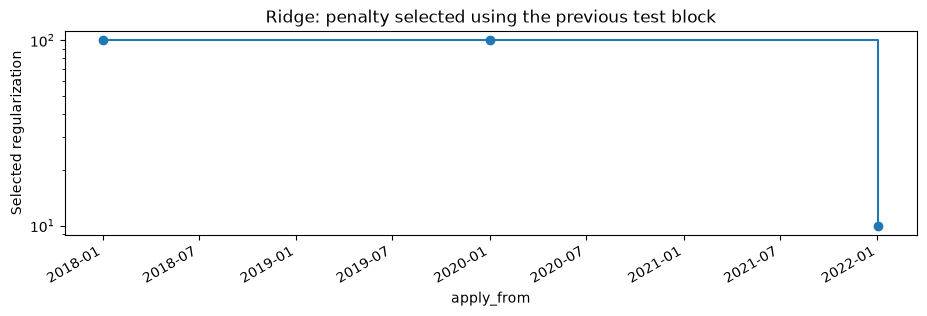

### Lasso: selection audit

,fold,validation_fold,selected_alpha,validation_start,validation_stop,validation_rows,validation_mse,predict_start,predict_stop,status,validation_first,validation_last,apply_from
0,1,0,0.00003,150191,300383,137725,1.883696e-07,300384,450720,selected,2016-01-03 18:00:00-05:00,2018-01-02 05:55:00-05:00,2018-01-02 06:05:00-05:00
1,2,1,0.00030,300384,450719,137889,3.755532e-07,450720,600911,selected,2018-01-02 06:05:00-05:00,2020-01-02 05:55:00-05:00,2020-01-02 06:05:00-05:00
2,3,2,0.00001,450720,600910,138845,8.768311e-07,600911,640734,selected,2020-01-02 06:05:00-05:00,2021-12-31 17:50:00-05:00,2022-01-02 18:00:00-05:00


candidate,0.000001,0.000003,0.000010,0.000030,0.000100,0.000300
fold,,,,,,
0,1.920851e-07,1.892377e-07,1.883839e-07,1.883696e-07,1.883696e-07,1.883696e-07
1,3.769389e-07,3.756568e-07,3.755532e-07,3.755532e-07,3.755532e-07,3.755532e-07
2,8.820294e-07,8.775785e-07,8.768311e-07,8.768311e-07,8.768311e-07,8.768311e-07
3,8.964208e-07,8.954813e-07,8.953645e-07,8.956068e-07,8.956068e-07,8.956068e-07


LASSO_CHOICES
 fold  validation_fold  selected_alpha  validation_start  validation_stop  validation_rows  validation_mse  predict_start  predict_stop   status          validation_first           validation_last                apply_from
    1                0         0.00003            150191           300383           137725    1.883696e-07         300384        450720 selected 2016-01-03 18:00:00-05:00 2018-01-02 05:55:00-05:00 2018-01-02 06:05:00-05:00
    2                1         0.00030            300384           450719           137889    3.755532e-07         450720        600911 selected 2018-01-02 06:05:00-05:00 2020-01-02 05:55:00-05:00 2020-01-02 06:05:00-05:00
    3                2         0.00001            450720           600910           138845    8.768311e-07         600911        640734 selected 2020-01-02 06:05:00-05:00 2021-12-31 17:50:00-05:00 2022-01-02 18:00:00-05:00


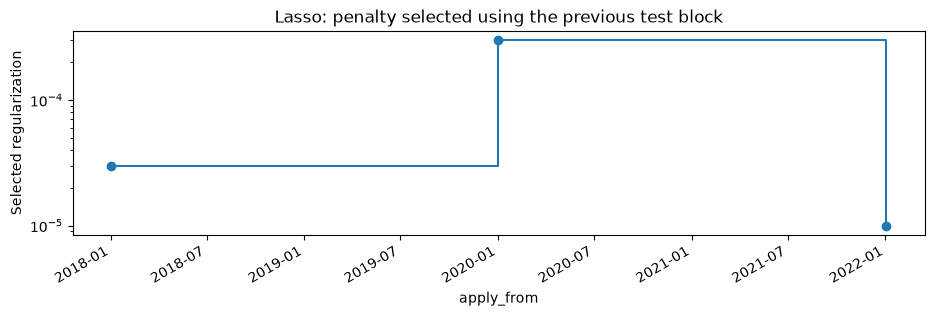

,daily_sharpe,pnl_observations,max_abs_weight,n,slope,intercept,correlation,rmse,zero_forecast_rmse
model,,,,,,,,,
Ridge,0.058400,308367,3.0,308367,0.897482,-0.000001,0.008532,0.000818,0.000818
Lasso,0.059164,308367,3.0,308367,1.174503,-0.000002,0.006984,0.000818,0.000818


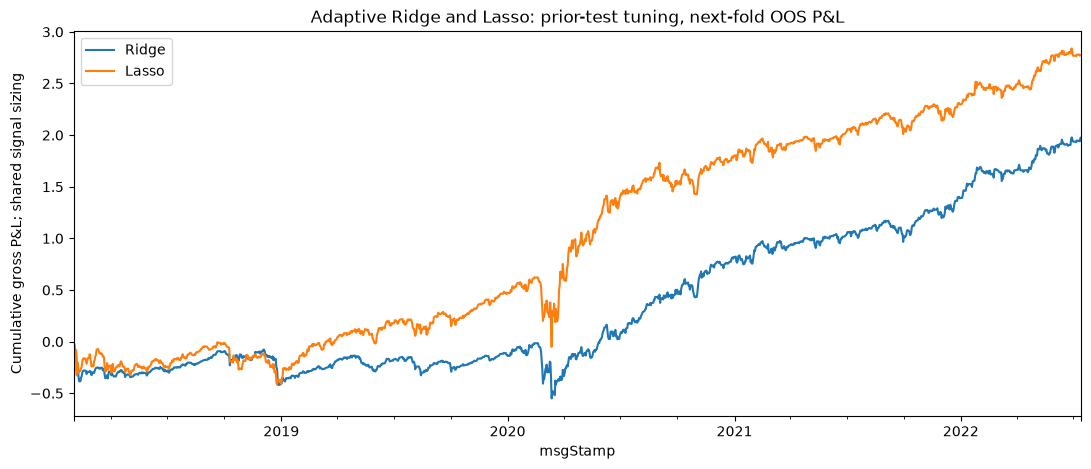

BATCH_SECONDS 3.3673864239999602


In [8]:
models = {('Ridge', float(a)): BatchRidge(len(fit_columns), alpha=float(a), **RIDGE_CONFIG)
          for a in RIDGE_ALPHAS}
models.update({('Lasso', float(a)): BatchLasso(len(fit_columns), DECAY, float(a),
              fit_intercept=True, tol=1e-11) for a in LASSO_ALPHAS})
started = perf_counter()
batch_paths = walk_forward_sweep(models, X_fit, y_fit, W=W_fit, **FOLD)
batch_seconds = perf_counter()-started
selections = {}
for family in ('Ridge', 'Lasso'):
    paths = {a: path for (kind,a),path in batch_paths.items() if kind == family}
    selections[family] = select_walk_forward_paths(paths, y_fit, weights=W_fit, embargo=SELECTION_EMBARGO)
    chosen = selections[family]
    table = chosen.selection_.rename(columns={'candidate':'selected_alpha'}).copy()
    table['validation_first'] = [df.index[int(i)] for i in table.validation_start]
    table['validation_last'] = [df.index[int(i)-1] for i in table.validation_stop]
    table['apply_from'] = [df.index[int(i)] for i in table.predict_start]
    display(Markdown(f'### {family}: selection audit'), table,
            chosen.validation_scores_.pivot(index='fold',columns='candidate',values='mse'))
    print(f'{family.upper()}_CHOICES'); print(table.to_string(index=False))
    assert chosen.choices_[0] is None and np.isnan(chosen.prediction_[:OOS_FIRST]).all()
    assert (table.validation_stop < table.predict_start).all()
    table.set_index('apply_from').selected_alpha.plot(drawstyle='steps-post', logy=True,
        marker='o', figsize=(11,3), title=f'{family}: penalty selected using the previous test block')
    plt.ylabel('Selected regularization'); plt.show(); plt.close('all')
ridge_selected, lasso_selected = selections['Ridge'], selections['Lasso']
batch_daily, batch_records = {}, []
for family, chosen in selections.items():
    daily, stats = score_prediction(oos_series(chosen.prediction_))
    batch_daily[family] = daily
    batch_records.append(dict(model=family, **stats))
batch_metrics = pd.DataFrame(batch_records).set_index('model')
display(batch_metrics)
pd.DataFrame(batch_daily).cumsum().plot(figsize=(13,5), title='Adaptive Ridge and Lasso: prior-test tuning, next-fold OOS P&L')
plt.ylabel('Cumulative gross P&L; shared signal sizing'); plt.show(); plt.close('all')
print('BATCH_SECONDS', batch_seconds)
assert batch_metrics.max_abs_weight.max() <= SIGNAL_RULE['cap']


### Why can Ridge backtests be very large?

Ridge shrinkage makes return forecasts small. The legacy $\hat y/\sigma_{\hat y}^2$ then **increases** exposure as forecast amplitude shrinks. A nearly constant nonzero intercept can also coexist with a tiny centered standard deviation. Changing the walk-forward window does not, by itself, bound that division.

The old normalization notebook's Original shape curve multiplies legacy exposure by the first observed scale. This removes units dependence, **not** concentration in a few bars. The audit below reconstructs both controls on the **same combined-feature, prior-test-selected Ridge forecasts and matched rows**, then compares the selected lagged std/floor/cap rule. Large-return days remain visible; no return or P&L is clipped.

<span style="color:red">TODO — Ridge sizing: investigate an uncertainty-aware t-stat score instead of yhat/ewm_std(yhat). A forecast t-stat would divide by an estimated forecast standard error, not by the temporal volatility of forecasts; define a valid uncertainty estimate for regularization and serial dependence before implementing it. The current stabilizer is the explicit floor/cap, not a claimed t-stat implementation.</span>


,observations,max_abs_weight,p99_abs_weight,max_abs_bar_pnl,max_abs_day_pnl,max_abs_day_over_daily_std,top10_abs_pnl_share,daily_mean_over_std,capped_percent
rule,,,,,,,,,
Legacy raw units,308367,1.415028e+07,4.468545e+06,218112.605388,171215.628123,11.278775,0.590265,0.056018,0.000000
Original shape,308367,1.476044e+01,4.661228e+00,0.227518,0.178598,11.278775,0.590265,0.056018,0.000000
Prior variance,308367,1.539939e+01,4.663513e+00,0.233785,0.170252,10.776640,0.610541,0.056798,0.000000
Floored variance + cap,308367,3.000000e+00,3.000000e+00,0.085714,0.161861,11.629282,0.306705,0.052121,10.597762
Std + floor + cap,308367,3.000000e+00,3.000000e+00,0.085714,0.200877,9.654955,0.243490,0.058400,29.338418
RMS + floor + cap,308367,3.000000e+00,3.000000e+00,0.085714,0.158483,12.006953,0.414417,0.059932,1.089611


ADAPTIVE_RIDGE_SIZING
                        observations  max_abs_weight  p99_abs_weight  max_abs_bar_pnl  max_abs_day_pnl  max_abs_day_over_daily_std  top10_abs_pnl_share  daily_mean_over_std  capped_percent
rule                                                                                                                                                                                        
Legacy raw units              308367    1.415028e+07    4.468545e+06    218112.605388    171215.628123                   11.278775             0.590265             0.056018        0.000000
Original shape                308367    1.476044e+01    4.661228e+00         0.227518         0.178598                   11.278775             0.590265             0.056018        0.000000
Prior variance                308367    1.539939e+01    4.663513e+00         0.233785         0.170252                   10.776640             0.610541             0.056798        0.000000
Floored variance + cap        308

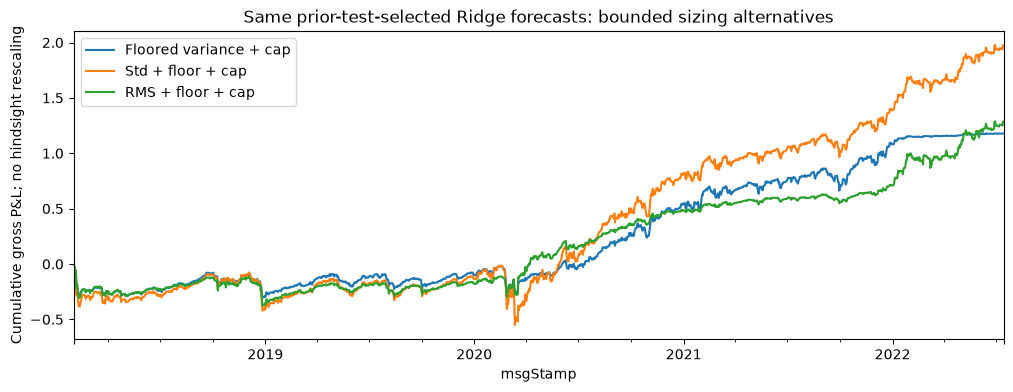

In [9]:
SIZING_RULES = {
    'Legacy raw units': None,
    'Original shape': dict(method='variance', floor_fraction=0, cap=None, lag=0),
    'Prior variance': dict(method='variance', floor_fraction=0, cap=None, lag=1),
    'Floored variance + cap': dict(method='variance', floor_fraction=.25, cap=3., lag=1),
    'Std + floor + cap': SIGNAL_RULE,
    'RMS + floor + cap': dict(method='rms', floor_fraction=.25, cap=3., lag=1),
}

def compare_sizing(prediction, returns, first_row):
    positions = pd.DataFrame({name: (prediction.div(ts_std(prediction, HL).pow(2))
        if rule is None else signal_weights(prediction, HL, **rule))
        for name, rule in SIZING_RULES.items()})
    common = positions.notna().all(axis=1) & np.isfinite(returns) & (np.arange(len(returns)) >= first_row)
    positions = positions.where(common, axis=0)
    contributions = positions.mul(returns, axis=0)
    daily = contributions.resample('D').sum().loc[returns.index[first_row].normalize():]
    records = []
    for name in positions:
        w = positions[name].dropna().abs(); p = contributions[name].dropna()
        total = p.abs().sum(); sigma = daily[name].std()
        records.append(dict(rule=name, observations=len(w), max_abs_weight=w.max(),
            p99_abs_weight=w.quantile(.99), max_abs_bar_pnl=p.abs().max(),
            max_abs_day_pnl=daily[name].abs().max(),
            max_abs_day_over_daily_std=daily[name].abs().max()/sigma if sigma > 0 else np.nan,
            top10_abs_pnl_share=100*p.abs().nlargest(10).sum()/total if total > 0 else np.nan,
            daily_mean_over_std=sharpe(daily[name]),
            capped_percent=100*w.ge(3.-1e-12).mean() if SIZING_RULES[name] is not None and SIZING_RULES[name].get('cap') is not None else 0.))
    return pd.DataFrame(records).set_index('rule'), positions, contributions, daily

# The audit now uses the adaptive Ridge prediction, not a fixed-alpha reference.
prediction = oos_series(ridge_selected.prediction_)
ridge_sizing, positions, contributions, selected_sizing_daily = compare_sizing(prediction, df.ret_5m, SCORE_FIRST)
display(ridge_sizing)
print('ADAPTIVE_RIDGE_SIZING'); print(ridge_sizing.to_string())
for name, rule in SIZING_RULES.items():
    if rule is not None and rule.get('cap') is not None:
        assert positions[name].abs().max() <= rule['cap']
selected_sizing_daily[['Floored variance + cap','Std + floor + cap','RMS + floor + cap']].cumsum().plot(
    figsize=(12,4), title='Same prior-test-selected Ridge forecasts: bounded sizing alternatives')
plt.ylabel('Cumulative gross P&L; no hindsight rescaling'); plt.show(); plt.close('all')


## Streaming Lasso: replay the prior-test-selected penalty schedule

The batch Lasso's preceding-test choice is now the **shared Lasso schedule** for the frozen streaming implementation audit and its live-update comparator. It is not replaced with a constant or chosen after viewing the streaming backtest. At each new fold, both comparators start from that fold's two-year training interval and chosen alpha. The frozen snapshot is held through the test block; the live comparator subsequently updates after each prediction. Thus live has additional within-block observed information, but no extra access for hyperparameter selection.

Only selected models are replayed, rather than maintaining a full online grid that will not be submitted. The independent batch grid supplies the OOS selection data. Intermediate training nonconvergence and terminal/live update status are reported separately. An invalid diagnostic fold is excluded as an explicitly failed solver result, never used to replace the chosen alpha. The final submission remains Ridge.


/home/runner/work/th/th/src/takehome/selection.py:186: RuntimeWarning: 1 updates did not converge; inspect KKT errors or raise max_iter.
  model.fit(X[a:b], y[a:b], W=w[a:b])


,fold,alpha,train_start,train_stop,terminal_converged,terminal_kkt,training_nonconverged_updates,live_nonconverged_updates,frozen_rmse,frozen_max_error
0,1,0.00003,150191,300383,True,0.000000e+00,1,0,1.140003e-14,2.632800e-13
1,2,0.00030,300384,450719,True,0.000000e+00,0,0,2.684083e-16,5.481008e-15
2,3,0.00001,450720,600910,True,8.045898e-11,0,0,4.301561e-10,6.987766e-09


SELECTED_STREAM_AUDIT
 fold   alpha  train_start  train_stop  terminal_converged  terminal_kkt  training_nonconverged_updates  live_nonconverged_updates  frozen_rmse  frozen_max_error
    1 0.00003       150191      300383                True  0.000000e+00                              1                          0 1.140003e-14      2.632800e-13
    2 0.00030       300384      450719                True  0.000000e+00                              0                          0 2.684083e-16      5.481008e-15
    3 0.00001       450720      600910                True  8.045898e-11                              0                          0 4.301561e-10      6.987766e-09


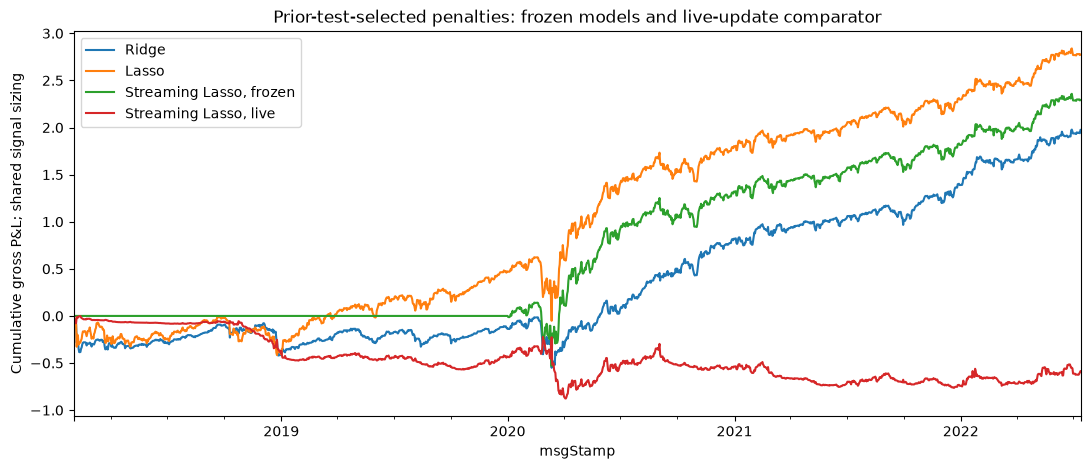

STREAM_SECONDS 178.09157362299993


In [10]:
started = perf_counter()
stream_result = stream_selected_folds(lasso_selected, X_fit, y_fit, W=W_fit,
                                      tol=1e-10, max_iter=20000)
stream_audit = stream_result['audit']
display(stream_audit)
print('SELECTED_STREAM_AUDIT'); print(stream_audit.to_string(index=False))
comparison_daily = dict(batch_daily)
for name, key in [('Streaming Lasso, frozen','frozen'), ('Streaming Lasso, live','live')]:
    prediction = oos_series(stream_result[key])
    for _, audit in stream_audit.iterrows():
        usable = bool(audit.terminal_converged) and (key=='frozen' or audit.live_nonconverged_updates==0)
        if not usable:
            f = folds[int(audit.fold)]
            prediction.iloc[f['predict_start']:f['predict_stop']] = np.nan
            print('INVALID SOLVER DIAGNOSTIC:', name, 'fold', int(audit.fold), '; not treated as valid performance')
    daily, stats = score_prediction(prediction)
    comparison_daily[name] = daily
comparison_daily = pd.DataFrame(comparison_daily)
comparison_daily.cumsum().plot(figsize=(13,5), title='Prior-test-selected penalties: frozen models and live-update comparator')
plt.ylabel('Cumulative gross P&L; shared signal sizing'); plt.show(); plt.close('all')
print('STREAM_SECONDS', perf_counter()-started)


### Independent numerical audit at the selected regularization values

Check streaming frozen forecasts against the batch prediction for the exact same two-year training window and previously chosen alpha. At each selected cutoff, compare an independent row-residual CVXPY solve and batch solve over a smaller real-data slice using that fold's chosen penalty. These checks test numerical implementation, not an alternative hyperparameter selection procedure.


In [11]:
real_checks = []
for i, key in enumerate(lasso_selected.choices_):
    if key is None:
        continue
    stop = folds[i]['train_stop']; start = max(folds[i]['train_start'], stop-4096)
    xx, yy, ww = X_fit[start:stop], y_fit[start:stop], W_fit[start:stop]
    direct = CvxpyWeightedLasso(len(fit_columns), DECAY, float(key), fit_intercept=True, tol=1e-12).fit(xx, yy, W=ww)
    fast = BatchLasso(len(fit_columns), DECAY, float(key), fit_intercept=True, tol=1e-12).fit(xx, yy, W=ww)
    real_checks.append(dict(fold=i, alpha=key, rows=stop-start,
        max_prediction_error=float(np.max(abs(fast.predict(xx)-direct.predict(xx)))),
        objective_gap=abs(fast.objective_-direct.objective_)))
real_checks = pd.DataFrame(real_checks)
display(real_checks)
print('REAL_SELECTED_CVXPY_CHECKS'); print(real_checks.to_string(index=False))
assert real_checks.max_prediction_error.max() < 2e-6


,fold,alpha,rows,max_prediction_error,objective_gap
0,1,0.00003,4096,2.449873e-17,1.952146e-22
1,2,0.00030,4096,7.623297e-21,0.000000e+00
2,3,0.00001,4096,2.709015e-12,3.255783e-21


REAL_SELECTED_CVXPY_CHECKS
 fold   alpha  rows  max_prediction_error  objective_gap
    1 0.00003  4096          2.449873e-17   1.952146e-22
    2 0.00030  4096          7.623297e-21   0.000000e+00
    3 0.00001  4096          2.709015e-12   3.255783e-21


## Selected Ridge coefficient path and OOS calibration

Each coefficient vector belongs to a fit using observations before that forecast fold and the alpha selected on the preceding test block. It is constant within the two-year forecast block. The plot therefore displays **fold snapshots**, rather than expanding a large row-level coefficient matrix. The first `HL` prediction rows are omitted from display/warm-up as before. Reconstruct the prediction from its exact matching snapshot with **no additional shift**: these coefficients are already aligned to their future test block.


In [12]:
# Already-OOS snapshots: do not shift again or apply a new fold backward.
yhat = pd.Series(np.nan, index=df.index, name='forecast')
for fold, coef, bias in zip(ridge_selected.path_.folds_, ridge_selected.path_.snapshots_, ridge_selected.path_.offsets_):
    first, stop = fold['predict_start'], fold['predict_stop']
    yhat.iloc[first:stop] = X_fit[first:stop] @ coef + bias
np.testing.assert_allclose(yhat, ridge_selected.prediction_, rtol=1e-11, atol=1e-12, equal_nan=True)


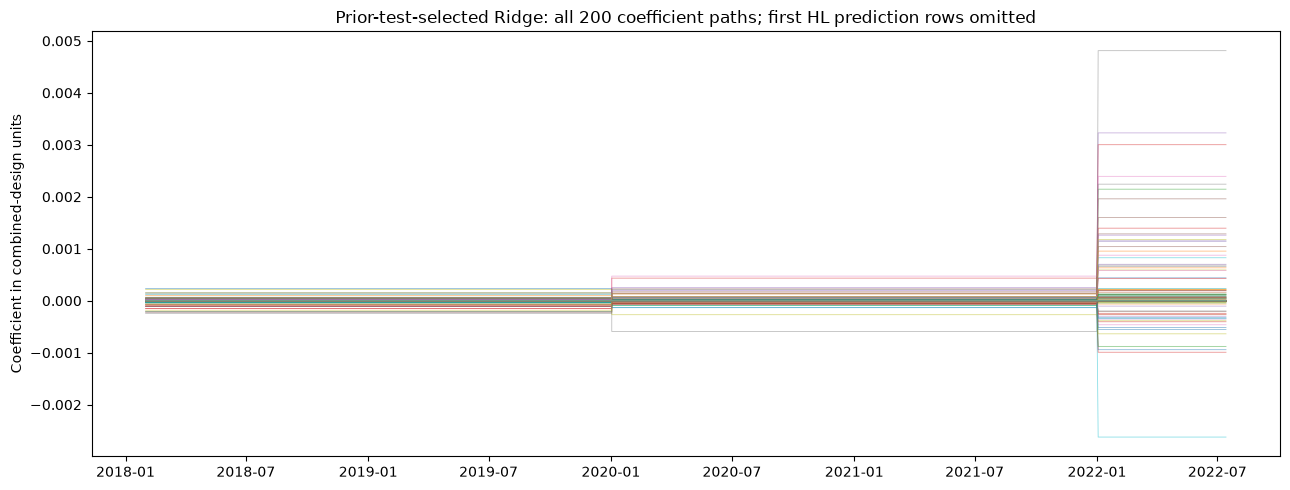

In [13]:
# Plot every combined-feature coefficient without allocating T x 200 histories.
plot_dates, plot_values = [], []
for fold, coef in zip(ridge_selected.path_.folds_, ridge_selected.path_.snapshots_):
    first, stop = max(fold['predict_start'], SCORE_FIRST), fold['predict_stop']
    if first < stop:
        plot_dates += [df.index[first], df.index[stop-1]]
        plot_values += [coef, coef]
beta_plot = pd.DataFrame(plot_values, index=plot_dates, columns=fit_columns)
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(beta_plot.index, beta_plot.to_numpy(), linewidth=.6, alpha=.5)
ax.set_title('Prior-test-selected Ridge: all 200 coefficient paths; first HL prediction rows omitted')
ax.set_ylabel('Coefficient in combined-design units'); fig.tight_layout(); plt.show(); plt.close(fig)


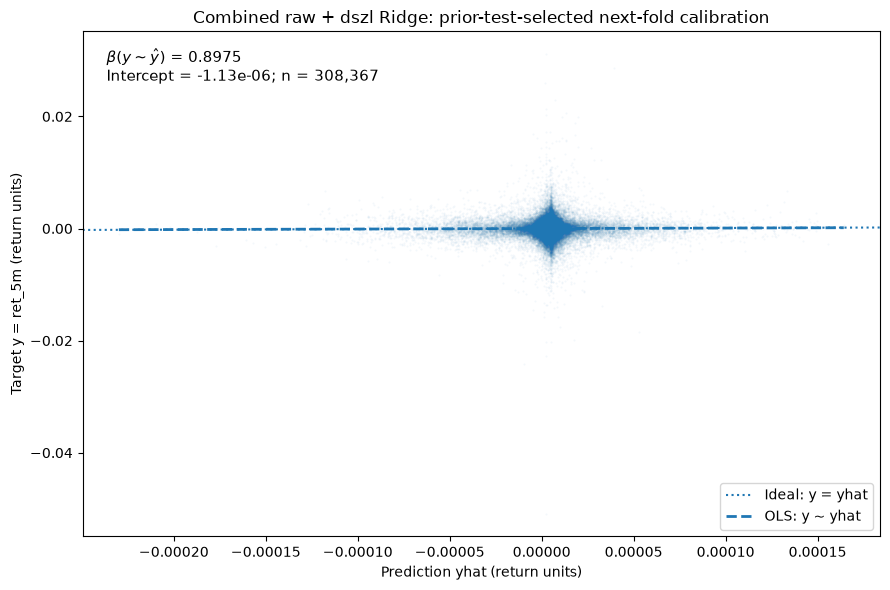

,n,slope,intercept,r_squared
OLS,308367,0.897482,-0.000001,0.000073


In [14]:
calibration = plot_calibration(yhat.where(rows>=SCORE_FIRST), df.ret_5m,
    title='Combined raw + dszl Ridge: prior-test-selected next-fold calibration')
display(calibration)


## Final modeling procedure and its non-holdout backtest

The final **procedure**, not a fixed penalty, is now validated: `[X, dszl(X, 10)]`, all 200 columns; Ridge with an unpenalized intercept; unit weights on observed targets; the 6,048-row fitting half-life; and rolling two-year training/forecast windows. Each alpha is chosen by preceding-test raw-return MSE and then locked for the next fold. Ties favor stronger shrinkage; a missing validation score cannot trigger a static fallback.

Raw and time-of-day-scaled features can carry complementary information. Including both avoids discarding either representation, while Ridge regularizes their strong correlation and keeps a distributed combination. Candidate MSE tables, changing alpha choices, Lasso comparisons and raw calibration are shown above. The next curve evaluates exactly this adaptive procedure; it is **not** the retrospectively best constant alpha. The next-fold validation claims do not extend to the initial tuning block.

The final holdout alpha is selected with the same rule on the latest completed two-year labeled test interval. That interval is outside the earlier research charts and is now explicitly a validation set, not an untouched statistical holdout. No target from the actual blackout is used. Signal sizing remains a distinct diagnostic policy; it never changes the raw forecasts written for submission. Gross backtests still exclude transaction costs and require confirmation of decision-time input availability.


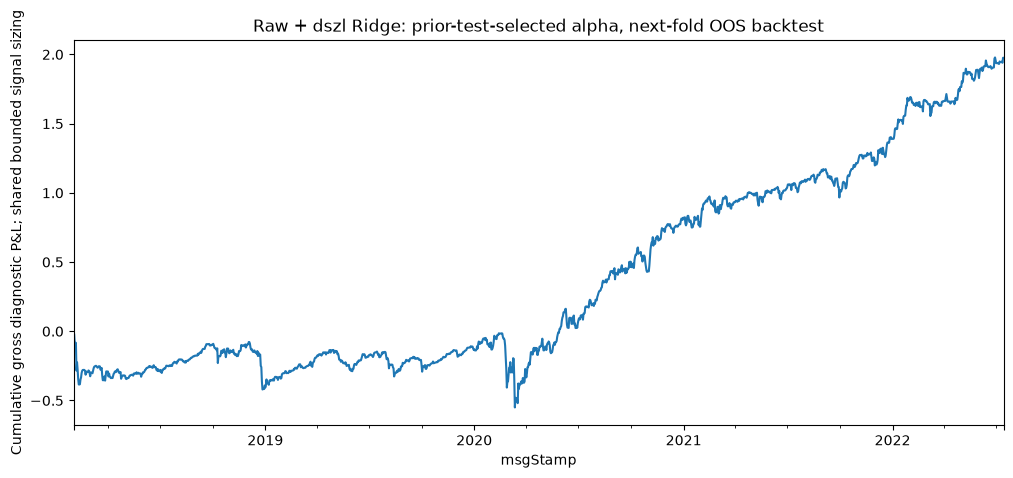

,research_validation
daily_sharpe,0.058400
pnl_observations,308367.000000
max_abs_weight,3.000000
n,308367.000000
slope,0.897482
intercept,-0.000001
correlation,0.008532
rmse,0.000818
zero_forecast_rmse,0.000818


,fold,validation_fold,candidate,validation_start,validation_stop,validation_rows,validation_mse,predict_start,predict_stop,status
0,1,0,100.0,150191,300383,137725,1.883719e-07,300384,450720,selected
1,2,1,100.0,300384,450719,137889,3.755647e-07,450720,600911,selected
2,3,2,10.0,450720,600910,138845,8.767401e-07,600911,640734,selected


ADAPTIVE_RIDGE_VALIDATION
daily_sharpe               0.058400
pnl_observations      308367.000000
max_abs_weight             3.000000
n                     308367.000000
slope                      0.897482
intercept                 -0.000001
correlation                0.008532
rmse                       0.000818
zero_forecast_rmse         0.000818
Forecasted rows inside research: 340350


In [15]:
selected_prediction = pd.Series(ridge_selected.prediction_, index=df.index, name='forecast')
selected_daily, selected_stats = score_prediction(selected_prediction)
selected_position = signal_weights(selected_prediction, HL, **SIGNAL_RULE).where(rows>=SCORE_FIRST)
assert selected_position.abs().max() <= SIGNAL_RULE['cap']
selected_daily.cumsum().plot(figsize=(12,5),
    title='Raw + dszl Ridge: prior-test-selected alpha, next-fold OOS backtest')
plt.ylabel('Cumulative gross diagnostic P&L; shared bounded signal sizing')
plt.show(); plt.close('all')
selected_metrics = pd.Series(selected_stats, name='research_validation')
display(selected_metrics.to_frame(), ridge_selected.selection_)
print('ADAPTIVE_RIDGE_VALIDATION'); print(selected_metrics.to_string())
print('Forecasted rows inside research:', int(selected_prediction.notna().sum()))
assert selected_prediction.dropna().index.max() < split['cutoff']


## Execution environment

Versions used for this evaluation are shown here, rather than exported to a separate file. The figures and statistical results above remain training-only.

In [38]:
from importlib.metadata import version
import platform

print(f'Python {platform.python_version()}')
packages = ['numpy', 'pandas', 'scipy', 'statsmodels', 'matplotlib', 'pyarrow',
            'diptest', 'numba', 'cvxpy', 'clarabel', 'pandas_market_calendars', 'nbformat', 'nbclient', 'ipykernel']
display(pd.Series({p: version(p) for p in packages}, name='version').to_frame())

Python 3.13.15


,version
numpy,2.5.3
pandas,3.0.6
scipy,1.18.1
statsmodels,0.15.0
matplotlib,3.11.2
pyarrow,25.0.1
diptest,0.11.0
numba,0.68.0
cvxpy,1.9.3
clarabel,0.11.1


## Training-only summary and checks

In [16]:
assert df.index.max() < split['cutoff']
assert len(base_columns) == 100 and len(fit_columns) == 200
assert ridge_selected.choices_[0] is None and lasso_selected.choices_[0] is None
assert (ridge_selected.selection_.validation_stop < ridge_selected.selection_.predict_start).all()
print('Research rows:', len(df), '; raw + dszl model columns:', len(fit_columns))
print('Selected walk-forward scoring starts:', df.index[SCORE_FIRST])
print('All charts above remain inside research; final pre-holdout tuning follows separately.')


Research rows: 640734 ; raw + dszl model columns: 200
Selected walk-forward scoring starts: 2018-01-31 06:05:00-05:00
All charts above remain inside research; final pre-holdout tuning follows separately.


## Holdout forecast: select on the preceding test interval, then refit

At the final blackout boundary B, build two matched folds. First train every Ridge candidate on `[B-4 years, B-2 years)` and validate on `[B-2 years, B)`. Then choose its best raw-return MSE, refit that alpha on `[B-2 years, B)`, and freeze it throughout `[B, end]`. The same one-row training and validation embargo is applied. The terminal supplied timestamp is included. No blackout target participates in either choice or fit.

This final validation uses the formerly research-reserved labeled interval. Its candidate scores are explicitly tuning results and are **not** reported as another unbiased backtest. The same-clock-time feature state is carried from the original feature-history start, and the exact `[raw, dszl]` layout is retained across research, final selection and inference.

Only **`forecasts/predictions.parquet`** is written: a timezone-aware `msgStamp` index and one `forecast` column in raw `ret_5m` units. There are no CSVs, in-sample forecast files, coefficient dumps, metadata files or plots in that folder. The displayed final-selection table documents the chosen regularization value here.


In [17]:
# Release the combined research matrix and temporary histories before final inference.
import gc
for variable in ('X_fit', 'model_X', 'raw_features', 'positions', 'contributions', 'xx'):
    globals().pop(variable, None)
gc.collect()

final_boundary = file_last - pd.DateOffset(years=WINDOW_YEARS)
final_train_start = final_boundary - pd.DateOffset(years=WINDOW_YEARS)
final_validation_train_start = final_boundary - pd.DateOffset(years=2*WINDOW_YEARS)
final_labels = read_parquet_window(DATA_PATH, start=final_validation_train_start, columns=['ret_5m'])
final_index = final_labels.index
final_predict_mask = final_index >= final_boundary
assert final_predict_mask.any() and final_labels.loc[final_predict_mask, 'ret_5m'].isna().all(), 'Blackout has observed targets.'
assert final_validation_train_start >= split['first_label']
base_p = len(base_columns)
final_design = np.empty((len(final_index), 2*base_p), dtype=np.float64, order='C')
for start in range(0, base_p, BATCH_SIZE):
    names = base_columns[start:start+BATCH_SIZE]
    inputs = [c for c in names if c != 'x100']
    if 'x100' in names:
        inputs += ['cashflow', 'volume']
    history = read_parquet_window(DATA_PATH, start=split['first_label'], columns=inputs)
    if 'x100' in names:
        history['x100'] = history.cashflow.div(history.volume.replace(0, np.nan)).replace([np.inf,-np.inf],np.nan)
    block = raw_dszl_design(history[names], hl=DSZL_HL, batch_size=BATCH_SIZE).loc[final_index].to_numpy()
    width = len(names)
    final_design[:, start:start+width] = block[:, :width]
    final_design[:, base_p+start:base_p+start+width] = block[:, width:]
    del history, block
assert np.isfinite(final_design).all()
validation_start = int(final_index.searchsorted(final_train_start))
holdout_start = int(final_index.searchsorted(final_boundary))
submission_folds = [
    dict(train_start=0, train_stop=validation_start-SELECTION_EMBARGO,
         predict_start=validation_start, predict_stop=holdout_start),
    dict(train_start=validation_start, train_stop=holdout_start-SELECTION_EMBARGO,
         predict_start=holdout_start, predict_stop=len(final_index)),
]
print('Candidate training:', final_validation_train_start, 'to', final_train_start)
print('Final validation / subsequent refit:', final_train_start, 'to', final_boundary)
print('True holdout:', final_index[final_predict_mask][0], 'through', final_index[-1])


Candidate training: 2020-08-31 17:55:00-04:00 to 2022-08-31 17:55:00-04:00
Final validation / subsequent refit: 2022-08-31 17:55:00-04:00 to 2024-08-31 17:55:00-04:00
True holdout: 2024-09-01 18:00:00-04:00 through 2026-08-31 17:55:00-04:00


In [18]:
# SAME grid and selection rule as research, with no static-alpha fallback.
final_y = final_labels.ret_5m.to_numpy(dtype=float)
final_weights = np.isfinite(final_y).astype(float)
submission_candidates = {float(a): BatchRidge(len(fit_columns), alpha=float(a), **RIDGE_CONFIG)
                         for a in RIDGE_ALPHAS}
submission_selection = walk_forward_select(submission_candidates, final_design, final_y,
    W=final_weights, folds=submission_folds, embargo=SELECTION_EMBARGO)
submission_alpha = submission_selection.choices_[1]
assert submission_alpha is not None
assert np.isnan(submission_selection.prediction_[:holdout_start]).all()
submission_forecast = pd.DataFrame({'forecast': submission_selection.prediction_[holdout_start:]},
    index=final_index[holdout_start:].rename('msgStamp'))
assert submission_forecast.index.equals(final_labels.loc[final_predict_mask].index)
assert submission_forecast.index.is_unique and submission_forecast.index.is_monotonic_increasing
assert np.isfinite(submission_forecast.forecast).all()
display(submission_selection.validation_scores_.query('fold == 0'), submission_selection.selection_)
print('HOLDOUT_SELECTED_ALPHA', submission_alpha)
print('Finite raw-return holdout predictions:', len(submission_forecast))
display(submission_forecast.head(), submission_forecast.tail())


,fold,candidate,validation_start,validation_stop,n,mse
0,0,100.000000,150336,300672,140245,3.377942e-07
1,0,10.000000,150336,300672,140245,3.381277e-07
2,0,1.000000,150336,300672,140245,3.391599e-07
3,0,0.100000,150336,300672,140245,3.417937e-07
4,0,0.010000,150336,300672,140245,3.479310e-07
5,0,0.001000,150336,300672,140245,3.554945e-07
6,0,0.000100,150336,300672,140245,3.616652e-07
7,0,0.000010,150336,300672,140245,3.672499e-07
8,0,0.000001,150336,300672,140245,3.709449e-07


,fold,validation_fold,candidate,validation_start,validation_stop,validation_rows,validation_mse,predict_start,predict_stop,status
0,1,0,100.0,150336,300672,140245,3.377942e-07,300673,450721,selected


HOLDOUT_SELECTED_ALPHA 100.0
Finite raw-return holdout predictions: 150048


,forecast
msgStamp,
2024-09-01 18:00:00-04:00,0.000003
2024-09-01 18:05:00-04:00,0.000003
2024-09-01 18:10:00-04:00,0.000003
2024-09-01 18:15:00-04:00,0.000003
2024-09-01 18:20:00-04:00,0.000003


,forecast
msgStamp,
2026-08-31 17:35:00-04:00,0.000003
2026-08-31 17:40:00-04:00,0.000003
2026-08-31 17:45:00-04:00,0.000003
2026-08-31 17:50:00-04:00,0.000003
2026-08-31 17:55:00-04:00,0.000003


In [19]:
forecast_dir = Path(os.environ.get('FORECAST_OUTPUT_DIR', ROOT / 'forecasts'))
forecast_dir.mkdir(parents=True, exist_ok=True)
forecast_path = forecast_dir / 'predictions.parquet'
# Unexpected files are not silently deleted during an ordinary rerun.
unexpected = [p.name for p in forecast_dir.iterdir() if p.name != forecast_path.name]
if unexpected:
    raise RuntimeError(f'forecasts/ must contain only predictions.parquet; remove obsolete files: {unexpected}')
submission_forecast.to_parquet(forecast_path)
roundtrip = pd.read_parquet(forecast_path)
pd.testing.assert_frame_equal(roundtrip, submission_forecast)
assert list(forecast_dir.iterdir()) == [forecast_path]
assert list(roundtrip.columns) == ['forecast'] and roundtrip.index.name == 'msgStamp'
print('SUBMISSION_FILE', forecast_path.resolve())
print('ROWS', len(roundtrip), 'SELECTED_ALPHA', submission_alpha)


SUBMISSION_FILE /home/runner/work/th/th/forecasts/predictions.parquet
ROWS 150048 SELECTED_ALPHA 100.0


## Execution provenance

2026-10-04 01:07 UTC: all changed model sections were executed from a fresh kernel using the complete research sample: the 100 AR feature-forecast models with prior-test hyperparameter selection, the Ridge/Lasso grids on all 200 combined-design columns, selected streaming replays, numerical audit, calibration, adaptive backtest and final holdout-only Parquet export. No changed output was retained. Execution took 632.7 seconds. Unchanged data/feature-family EDA and h=0/h=1 oracle outputs are retained from the prior complete run; their source and inputs are unchanged. This is not a new full execution of the unchanged 4,950-product/9,900-residual experiments. `python run_eda.py` reproduces the entire notebook, including those experiments.
